# F1 2026 Japanese GP Qualifying Lap Time Prediction and Race Strategy

## Introduction

This notebook analyzes FP1-FP3 data from the 2026 Japanese Grand Prix to understand how practice-session behavior translates into qualifying-style lap pace. The workflow combines data preparation, exploratory analysis, and regression modeling to estimate lap time under controlled assumptions.

The goal is not just to rank teams by raw pace. It is to identify which combinations of session context, tyre state, driver identity, and speed indicators explain the lap-time variation seen before qualifying.

### Event Context

Suzuka Circuit rewards high-speed aerodynamic stability through “S” curves with committed cornering speed, and driver confidence in changes of direction. That makes lap time sensitive to front tyre wear over a full stint, fuel-load sensitivity through the high-speed sections, track evolution across the weekend, and the specific balance between qualifying one-lap pace and long-run degradation in high-grip conditions.

Using FP1-FP3 data from Mercedes, Red Bull Racing, Ferrari, and McLaren keeps the analysis focused on front-running pace while preserving enough variation for meaningful comparison and model training.

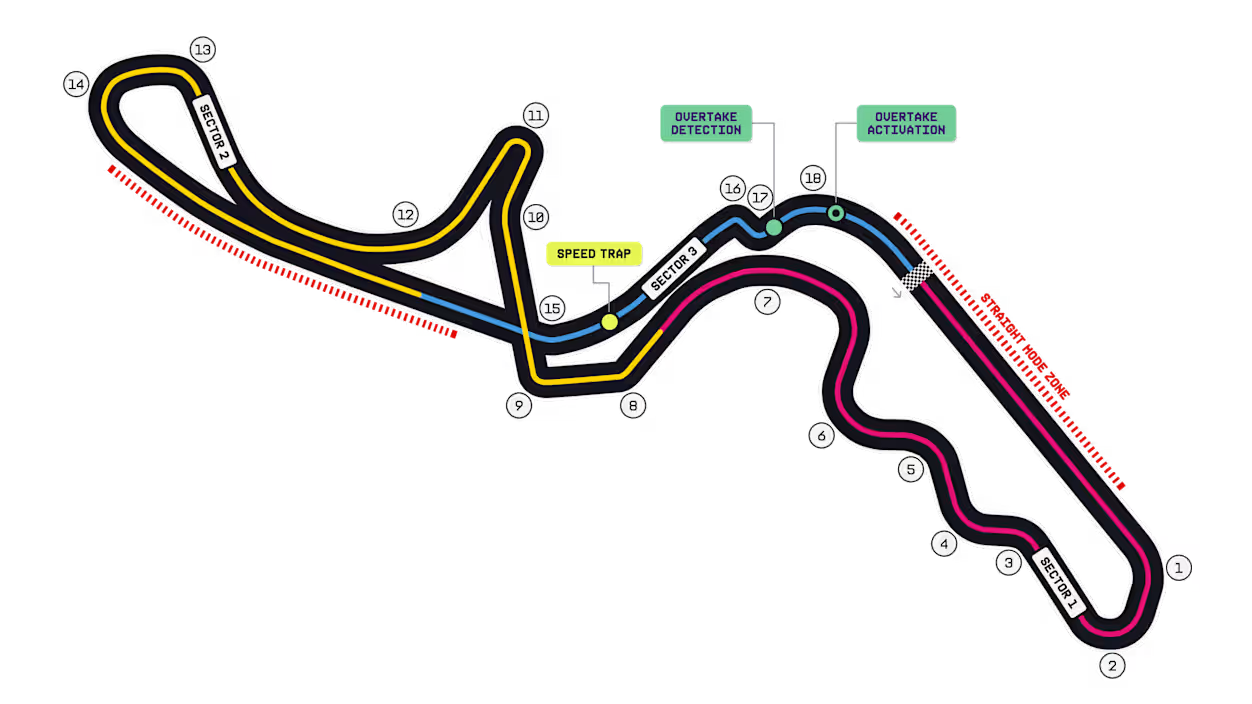 https://media.formula1.com/image/upload/c_fit,h_704/q_auto/v1740000001/common/f1/2026/track/2026tracksuzukadetailed.webp

| Circuit Length (KM) | Number of Laps | Race Distance (KM) | First Grand Prix | Fastest Lap Time | Driver | Team | Year |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 5.807 | 53 | 307.471 | 1987 | 1:30.965 (90.965 sec) | Kimi Antonelli | Mercedes | 2025 |

### Research Objectives

1. Quantify the main factors associated with lap-time variation across the selected top teams.
2. Examine how pace changes across sessions, stints, tyre compounds, and tyre life.
3. Benchmark ensemble regression models for qualifying-oriented lap-time prediction.
4. Translate the best model into a driver-level tyre-life sensitivity view for qualifying scenarios.

## Data Preparation

This section loads the Japanese GP practice data, checks whether local exports already exist, and rebuilds the dataset from FastF1 only when needed. The intent is to keep the notebook reproducible and fast to rerun while preserving a clear path from source data to modeling inputs.

In [34]:
# Importing libraries for data analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import fastf1 as ff1
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.utils import resample
from itertools import product

# Define event/session metadata once and reuse across notebook
year = 2026
gp = 'Japanese Grand Prix'
cache_gp = 'japanese_gp'
cache_data = f"./f1_{year}_{cache_gp}_cache"
session_names = ['FP1', 'FP2', 'FP3']
qualifying_session_name = 'Q'

# Define CSV file paths
csv_file = f'f1_{year}_{cache_gp}_combined_laps.csv'
cleaned_csv_file = f'f1_{year}_{cache_gp}_cleaned_laps.csv'
qualifying_csv_file = f'f1_{year}_{cache_gp}_qualifying_laps.csv'
qualifying_cleaned_csv_file = f'f1_{year}_{cache_gp}_qualifying_cleaned_laps.csv'
qualifying_top_teams_csv_file = f'f1_{year}_{cache_gp}_qualifying_top_teams_laps.csv'

# Race and pit constants
RACE_LAPS = 56
PIT_STOP_LOSS = 22.0
WARM_UP_LAPS = 3
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

# Keep a stable schema when qualifying is unavailable
qualifying_fallback_columns = [
    'Session', 'Team', 'Driver', 'DriverNumber', 'LapNumber', 'Stint',
    'LapTime', 'Compound', 'TyreLife', 'SpeedST', 'TrackStatus'
]

# Prepare cache and event
os.makedirs(cache_data, exist_ok=True)
ff1.Cache.enable_cache(cache_data)
event = ff1.get_event(year, gp)

# Shared session cache for downstream telemetry/map analysis
sessions_by_name = {}
session_laps_by_name = {}

def load_sessions_once(load_telemetry=True):
    for session_name in session_names:
        if session_name in sessions_by_name:
            continue
        try:
            print(f"Loading {session_name}")
            session = event.get_session(session_name)
            session.load(telemetry=load_telemetry, weather=False, messages=False)
            sessions_by_name[session_name] = session

            session_laps = session.laps.copy()
            session_laps['Session'] = session_name
            session_laps_by_name[session_name] = session_laps
            print(f"Loaded {len(session.laps)} laps from {session_name}")
        except Exception as exc:
            print(f"Warning: {session_name} unavailable or failed to load ({exc}). Skipping this session.")

def load_qualifying_laps():
    if os.path.exists(qualifying_csv_file):
        try:
            print(f"Loading qualifying data from existing CSV file: {qualifying_csv_file}")
            qualifying_data = pd.read_csv(qualifying_csv_file)
            print(f"Total qualifying laps in dataset: {len(qualifying_data)}")
            return qualifying_data
        except Exception as exc:
            print(f"Warning: failed reading qualifying CSV ({exc}). Retrying from FastF1.")

    print('Qualifying CSV file not found or unreadable. Pulling qualifying data from FastF1')
    try:
        qualifying_session = event.get_session(qualifying_session_name)
        qualifying_session.load(telemetry=False, weather=False, messages=False)
        sessions_by_name[qualifying_session_name] = qualifying_session

        qualifying_data = qualifying_session.laps.copy()
        qualifying_data['Session'] = qualifying_session_name
        qualifying_data.to_csv(qualifying_csv_file, index=False)
        print(f"Qualifying data saved to {qualifying_csv_file}")
        print(f"Total qualifying laps in dataset: {len(qualifying_data)}")
        return qualifying_data
    except Exception as exc:
        print(f"Warning: qualifying session unavailable ({exc}). Returning empty qualifying dataset.")
        return pd.DataFrame(columns=qualifying_fallback_columns)

# Check if CSV file already exists
if os.path.exists(csv_file):
    print(f"Loading data from existing CSV file: {csv_file}")
    data = pd.read_csv(csv_file)
    print(f"Total laps in dataset: {len(data)}")

    # Load sessions once here so telemetry/race-map cells can reuse them
    print("Preparing session cache for telemetry and race map")
    load_sessions_once(load_telemetry=True)
else:
    print("CSV file not found. Pulling data from FastF1")

    # Load multiple sessions once and combine them
    load_sessions_once(load_telemetry=True)
    all_laps = [session_laps_by_name[s] for s in session_names if s in session_laps_by_name]

    if len(all_laps) == 0:
        raise RuntimeError(
            "No practice sessions (FP1/FP2/FP3) could be loaded. "
            "Please check FastF1 cache/network availability or provide the combined CSV file."
        )

    data = pd.concat(all_laps, ignore_index=True)

    # Save the combined dataframe to a CSV file
    data.to_csv(csv_file, index=False)
    print(f"\nData saved to {csv_file}")
    print(f"Total laps in dataset: {len(data)}")

qualifying_data = load_qualifying_laps()

core           INFO 	Loading data for Japanese Grand Prix - Practice 1 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading data from existing CSV file: f1_2026_japanese_gp_combined_laps.csv
Total laps in dataset: 1512
Preparing session cache for telemetry and race map
Loading FP1


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '16', '18', '23', '27', '30', '31', '34', '41', '43', '44', '55', '63', '77', '81', '87']
core           INFO 	Loading data for Japanese Grand Prix - Practice 2 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loaded 529 laps from FP1
Loading FP2


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']
core           INFO 	Loading data for Japanese Grand Prix - Practice 3 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loaded 547 laps from FP2
Loading FP3


core        WARNING 	Driver 30: Lap timing integrity check failed for 1 lap(s)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']


Loaded 436 laps from FP3
Loading qualifying data from existing CSV file: f1_2026_japanese_gp_qualifying_laps.csv
Total qualifying laps in dataset: 324


### Data Preprocessing

This preprocessing step standardizes lap-level records before analysis.

1. Convert timing fields to numeric seconds.
2. Remove deleted or inaccurate laps that would distort pace comparisons.
3. Drop columns that are not required for this notebook's analysis path.
4. Export the cleaned dataset so the processed source can be reused consistently.

In [35]:
# Cleaning the data
def data_cleaning(data, output_csv_path):
    cleaned_data = data.copy()

    # Convert all time columns to seconds
    time_columns = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
    for col in time_columns:
        if col in cleaned_data.columns:
            # If already numeric (seconds), keep as-is
            if pd.api.types.is_numeric_dtype(cleaned_data[col]):
                cleaned_data[col] = pd.to_numeric(cleaned_data[col], errors='coerce')
            else:
                # Handle strings/timedelta-like values
                cleaned_data[col] = pd.to_timedelta(cleaned_data[col], errors='coerce').dt.total_seconds()

    # Remove deleted laps (commonly deleted for track limits)
    if 'Deleted' in cleaned_data.columns:
        deleted_mask = cleaned_data['Deleted'].astype(str).str.lower().isin(['true', '1', 'yes'])
        removed_count = int(deleted_mask.sum())
        cleaned_data = cleaned_data.loc[~deleted_mask].copy()
        print(f"Removed {removed_count} deleted laps.")

    # Remove inaccurate laps (e.g., those with missing or zero lap times)
    if 'IsAccurate' in cleaned_data.columns:
        accurate_mask = cleaned_data['IsAccurate'].astype(str).str.lower().isin(['false', '0', 'no'])
        accurate_count = int(accurate_mask.sum())
        cleaned_data = cleaned_data.loc[~accurate_mask].copy()
        print(f"Removed {accurate_count} inaccurate laps.")

    # Drop unnecessary columns (if any)
    columns_to_drop = ['Time', 'PitOutTime', 'PitInTime', 'PitDuration', 'LapStartTime', 'LapEndTime',
                       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'LapStartDateTime',
                       'LapStartDate', 'LapEndDateTime','Position', 'Deleted', 'DeletedReason', 'FastF1Generated','IsAccurate']
    cleaned_data = cleaned_data.drop(columns=[col for col in columns_to_drop if col in cleaned_data.columns])

    # Save the cleaned dataframe to a CSV file
    cleaned_data.to_csv(output_csv_path, index=False)
    print(f"Cleaned data saved to {output_csv_path}")
    return cleaned_data

In [36]:
df = data_cleaning(data, cleaned_csv_file)
qualifying_df = data_cleaning(qualifying_data, qualifying_cleaned_csv_file)

Removed 0 deleted laps.
Removed 576 inaccurate laps.
Cleaned data saved to f1_2026_japanese_gp_cleaned_laps.csv
Removed 0 deleted laps.
Removed 197 inaccurate laps.
Cleaned data saved to f1_2026_japanese_gp_qualifying_cleaned_laps.csv


### Data Inspection

The inspection cells check that the cleaned dataset is structurally sound before any EDA or modeling begins. They confirm the table size, available columns, lap-time distribution, and the team-driver coverage that the later sections rely on.

In [37]:
# Display all data
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print("\nColumn names:")
print(df.columns.tolist())

# Display the dataframe
df

Total rows: 936
Total columns: 19

Column names:
['Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'TrackStatus', 'Session']


,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Session
2,NOR,1,94.595,3.0,2.0,33.696,42.133,18.766,267.0,312.0,254.0,273.0,True,MEDIUM,3.0,False,McLaren,1,FP1
3,NOR,1,124.621,4.0,2.0,43.813,56.858,23.950,173.0,270.0,269.0,174.0,True,MEDIUM,4.0,False,McLaren,1,FP1
4,NOR,1,93.151,5.0,2.0,33.658,41.167,18.326,264.0,312.0,253.0,273.0,True,MEDIUM,5.0,False,McLaren,1,FP1
5,NOR,1,142.135,6.0,2.0,47.169,60.130,34.836,204.0,234.0,270.0,155.0,False,MEDIUM,6.0,False,McLaren,1,FP1
6,NOR,1,104.450,7.0,2.0,33.783,50.633,20.034,270.0,272.0,277.0,259.0,False,MEDIUM,7.0,False,McLaren,1,FP1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,BEA,87,92.378,4.0,1.0,33.640,40.671,18.067,275.0,324.0,252.0,279.0,True,MEDIUM,4.0,True,Haas F1 Team,1,FP3
1499,BEA,87,91.953,6.0,1.0,33.384,40.605,17.964,277.0,326.0,256.0,280.0,True,MEDIUM,6.0,True,Haas F1 Team,1,FP3
1501,BEA,87,91.558,8.0,1.0,33.368,40.445,17.745,278.0,327.0,264.0,281.0,True,MEDIUM,8.0,True,Haas F1 Team,1,FP3
1507,BEA,87,91.974,14.0,4.0,33.156,40.845,17.973,279.0,325.0,254.0,281.0,False,MEDIUM,12.0,False,Haas F1 Team,1,FP3


In [38]:
# Display basic info
print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nLapTime statistics:")
print(df['LapTime'].describe())

Dataset shape after cleaning: (936, 19)

LapTime statistics:
count    936.000000
mean     105.094613
std       16.542759
min       89.362000
25%       93.439250
50%       96.422500
75%      118.069500
max      149.492000
Name: LapTime, dtype: float64


In [39]:
# Display available teams and drivers
print("Available Teams:")
print(df['Team'].unique())
print("\nAvailable Drivers:")
print(df[['Driver', 'DriverNumber', 'Team']].drop_duplicates().sort_values('Team').reset_index(drop=True))

Available Teams:
['McLaren' 'Red Bull Racing' 'Audi' 'Alpine' 'Cadillac' 'Mercedes'
 'Ferrari' 'Aston Martin' 'Williams' 'Racing Bulls' 'Haas F1 Team']

Available Drivers:
   Driver  DriverNumber             Team
0     GAS            10           Alpine
1     COL            43           Alpine
2     ALO            14     Aston Martin
3     STR            18     Aston Martin
4     CRA            34     Aston Martin
5     BOR             5             Audi
6     HUL            27             Audi
7     BOT            77         Cadillac
8     PER            11         Cadillac
9     HAM            44          Ferrari
10    LEC            16          Ferrari
11    BEA            87     Haas F1 Team
12    OCO            31     Haas F1 Team
13    PIA            81          McLaren
14    NOR             1          McLaren
15    ANT            12         Mercedes
16    RUS            63         Mercedes
17    LIN            41     Racing Bulls
18    LAW            30     Racing Bulls
19    HA

In [40]:
# Display laps by each team
print("\nLaps by Team:")
laps_by_team = df['Team'].value_counts()
print(laps_by_team)


Laps by Team:
Team
Williams           105
Red Bull Racing     99
Alpine              98
Haas F1 Team        89
Ferrari             89
Audi                82
Mercedes            81
Racing Bulls        78
McLaren             77
Cadillac            76
Aston Martin        62
Name: count, dtype: int64


### Top-Team Filter

This filter keeps only Mercedes, Red Bull Racing, Ferrari, and McLaren. Restricting the sample to the leading teams reduces broad midfield noise and makes the pace comparisons, telemetry views, and qualifying projections more consistent with the notebook's objective.

In [41]:
# Filter for top teams and include all drivers from those teams
top_teams = ['Mercedes', 'Red Bull Racing', 'Ferrari', 'McLaren']
top_teams_csv = f'f1_2026_{cache_gp}_top_teams_laps.csv'

top_teams_df = df[df['Team'].isin(top_teams)].copy().reset_index(drop=True)
top_teams_df.to_csv(top_teams_csv, index=False)

qualifying_top_teams_df = qualifying_df[qualifying_df['Team'].isin(top_teams)].copy().reset_index(drop=True)
qualifying_top_teams_df.to_csv(qualifying_top_teams_csv_file, index=False)

print(f"Top-team data saved to '{top_teams_csv}' ({len(top_teams_df)} laps)")
print(f"Qualifying top-team data saved to '{qualifying_top_teams_csv_file}' ({len(qualifying_top_teams_df)} laps)")
print("\nLaps by top team:")
print(top_teams_df['Team'].value_counts())

print("\nQualifying laps by top team:")
print(qualifying_top_teams_df['Team'].value_counts())

print("\nDrivers by top team:")
print(
    top_teams_df[['Team', 'Driver', 'DriverNumber']]
    .drop_duplicates()
    .sort_values(['Team', 'Driver'])
    .reset_index(drop=True)
)

print("\nQualifying drivers by top team:")
print(
    qualifying_top_teams_df[['Team', 'Driver', 'DriverNumber']]
    .drop_duplicates()
    .sort_values(['Team', 'Driver'])
    .reset_index(drop=True)
)

print("\nSample laps from top teams:")
print(
    top_teams_df[['Team', 'Driver', 'LapNumber', 'Stint', 'LapTime', 'Compound', 'TyreLife', 'Session']]
    .head(15)
    .sort_values(['Team', 'Driver', 'LapTime'])
)

Top-team data saved to 'f1_2026_japanese_gp_top_teams_laps.csv' (346 laps)
Qualifying top-team data saved to 'f1_2026_japanese_gp_qualifying_top_teams_laps.csv' (57 laps)

Laps by top team:
Team
Red Bull Racing    99
Ferrari            89
Mercedes           81
McLaren            77
Name: count, dtype: int64

Qualifying laps by top team:
Team
Ferrari            18
McLaren            16
Mercedes           14
Red Bull Racing     9
Name: count, dtype: int64

Drivers by top team:
              Team Driver  DriverNumber
0          Ferrari    HAM            44
1          Ferrari    LEC            16
2          McLaren    NOR             1
3          McLaren    PIA            81
4         Mercedes    ANT            12
5         Mercedes    RUS            63
6  Red Bull Racing    HAD             6
7  Red Bull Racing    VER             3

Qualifying drivers by top team:
              Team Driver  DriverNumber
0          Ferrari    HAM            44
1          Ferrari    LEC            16
2      

## Exploratory Data Analysis

The EDA section examines pace distribution, session progression, stint structure, straight-line speed, telemetry shape, tyre effects, and degradation behavior. These checks provide the domain context needed to judge whether the feature set is informative enough for machine learning.

### Lap Time Distribution

Distribution plots show how each top team's lap times are spread across the practice weekend. The center of each distribution reflects competitive pace, while the tails capture traffic, out-laps, in-laps, cooldowns, and other non-push contexts.

Comparing histograms with boxplots is useful here because two teams can share similar medians while differing materially in variability. That difference matters for prediction error and for interpreting how stable each team's practice pace really was.

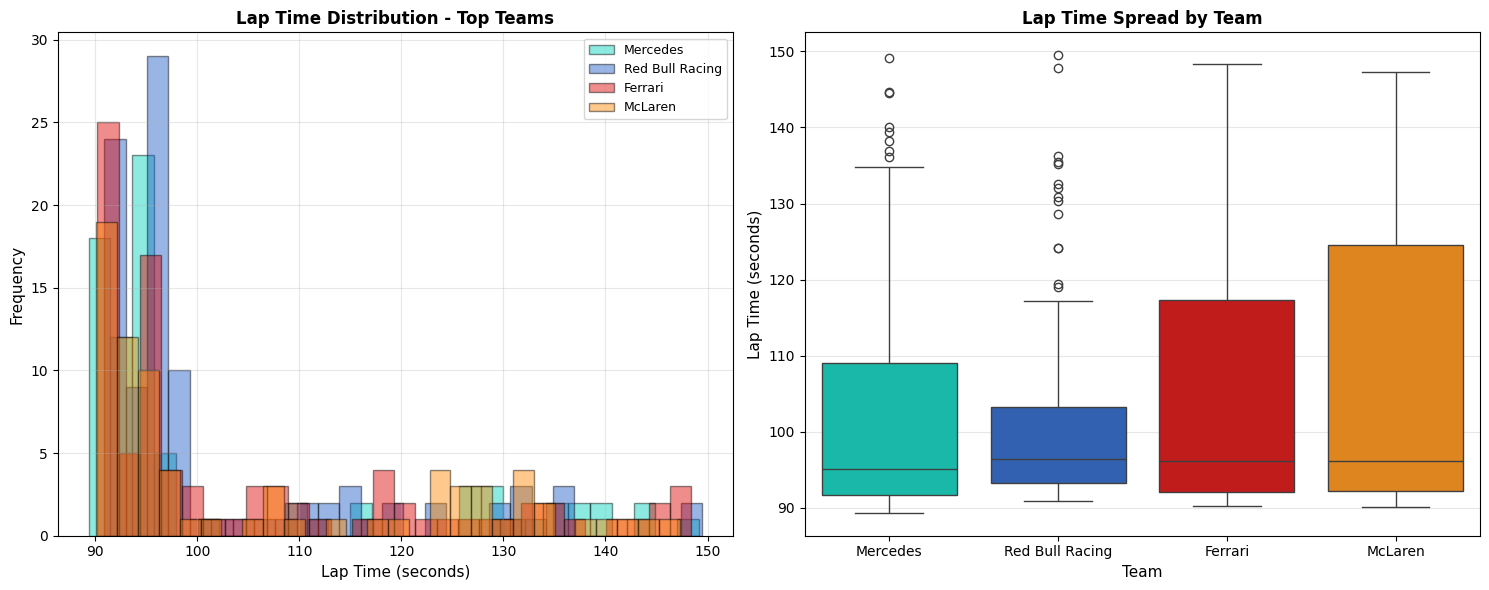

Top-Team Lap Time Summary:
                 count     mean     min     std
Team                                           
Mercedes            81  103.246  89.362  17.599
Red Bull Racing     99  102.080  90.910  13.842
Ferrari             89  105.422  90.229  17.383
McLaren             77  106.046  90.133  17.657


In [42]:
# Team-level lap time distribution for top teams
analysis_df = top_teams_df.copy()

team_palette = {
    'Mercedes': '#00D2BE',
    'Red Bull Racing': '#1E5BC6',
    'Ferrari': '#DC0000',
    'McLaren': '#FF8700'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram by team
for team in top_teams:
    team_laps = analysis_df[analysis_df['Team'] == team]['LapTime'].dropna()
    if not team_laps.empty:
        axes[0].hist(team_laps, bins=28, alpha=0.45, label=team, color=team_palette.get(team, 'gray'), edgecolor='black')

axes[0].set_xlabel('Lap Time (seconds)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Lap Time Distribution - Top Teams', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Boxplot by team
box_data = analysis_df[analysis_df['Team'].isin(top_teams)].copy()
sns.boxplot(
    data=box_data,
    x='Team',
    y='LapTime',
    hue='Team',
    palette=team_palette,
    order=top_teams,
    legend=False,
    ax=axes[1]
)
axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time Spread by Team', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

team_summary = (
    analysis_df.groupby('Team')['LapTime']
    .agg(['count', 'mean', 'min', 'std'])
    .reindex(top_teams)
    .round(3)
)

print('Top-Team Lap Time Summary:')
print(team_summary)

### Lap Time Trends by Session

Median lap-time traces by lap number show how pace evolves inside FP1, FP2, and FP3. Spikes and troughs usually reflect changes in run intention rather than pure car performance, so the session view helps separate recurring pace behavior from one-off operational noise.

FP3 is especially relevant because teams typically move closer to qualifying preparation, while FP1 and FP2 contain a broader mix of installation work, experimentation, and long-run programs.

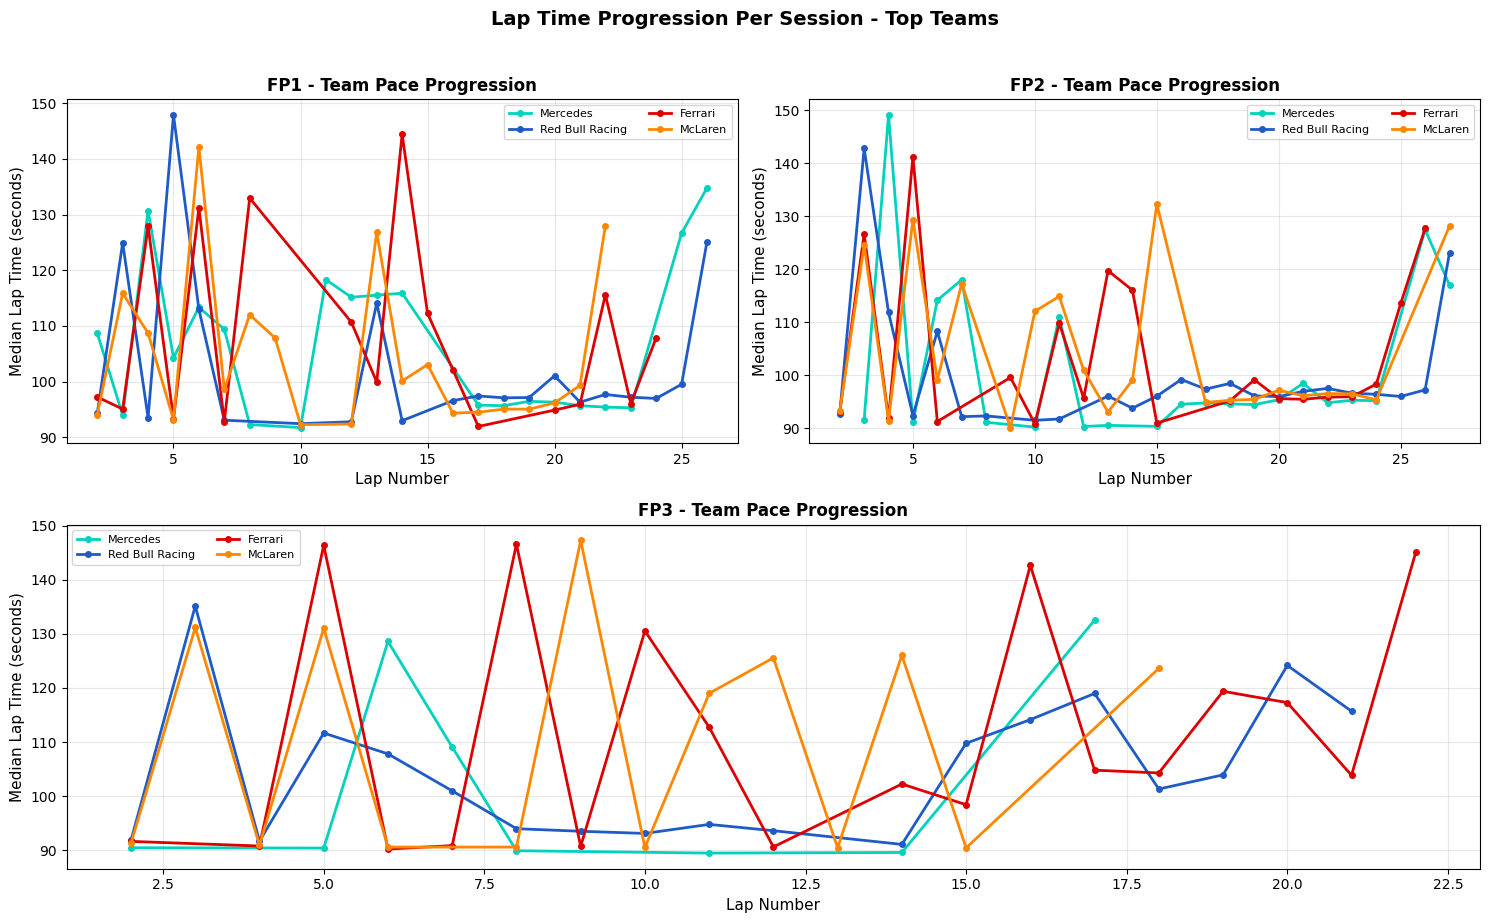

In [43]:
# Lap time progression by session and team (median pace by lap number)
session_names = ['FP1', 'FP2', 'FP3']

layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(15, 9))

for session_name in session_names:
    ax = axes[session_name]
    session_df = top_teams_df[top_teams_df['Session'] == session_name].copy()

    for team in top_teams:
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty:
            continue

        trend = (
            team_session.groupby('LapNumber', as_index=False)['LapTime']
            .median()
            .sort_values('LapNumber')
)

        ax.plot(
            trend['LapNumber'],
            trend['LapTime'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=team,
            color=team_palette.get(team, 'gray')
        )

    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Median Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Team Pace Progression', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle('Lap Time Progression Per Session - Top Teams', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Stint Pace Trends by Session

Averaging lap time by stint smooths some of the lap-to-lap volatility and makes each team's run structure easier to compare. These plots are best read as context-aware indicators: they combine tyre state, fuel load evolution, and execution quality rather than representing a pure ranking of intrinsic pace.

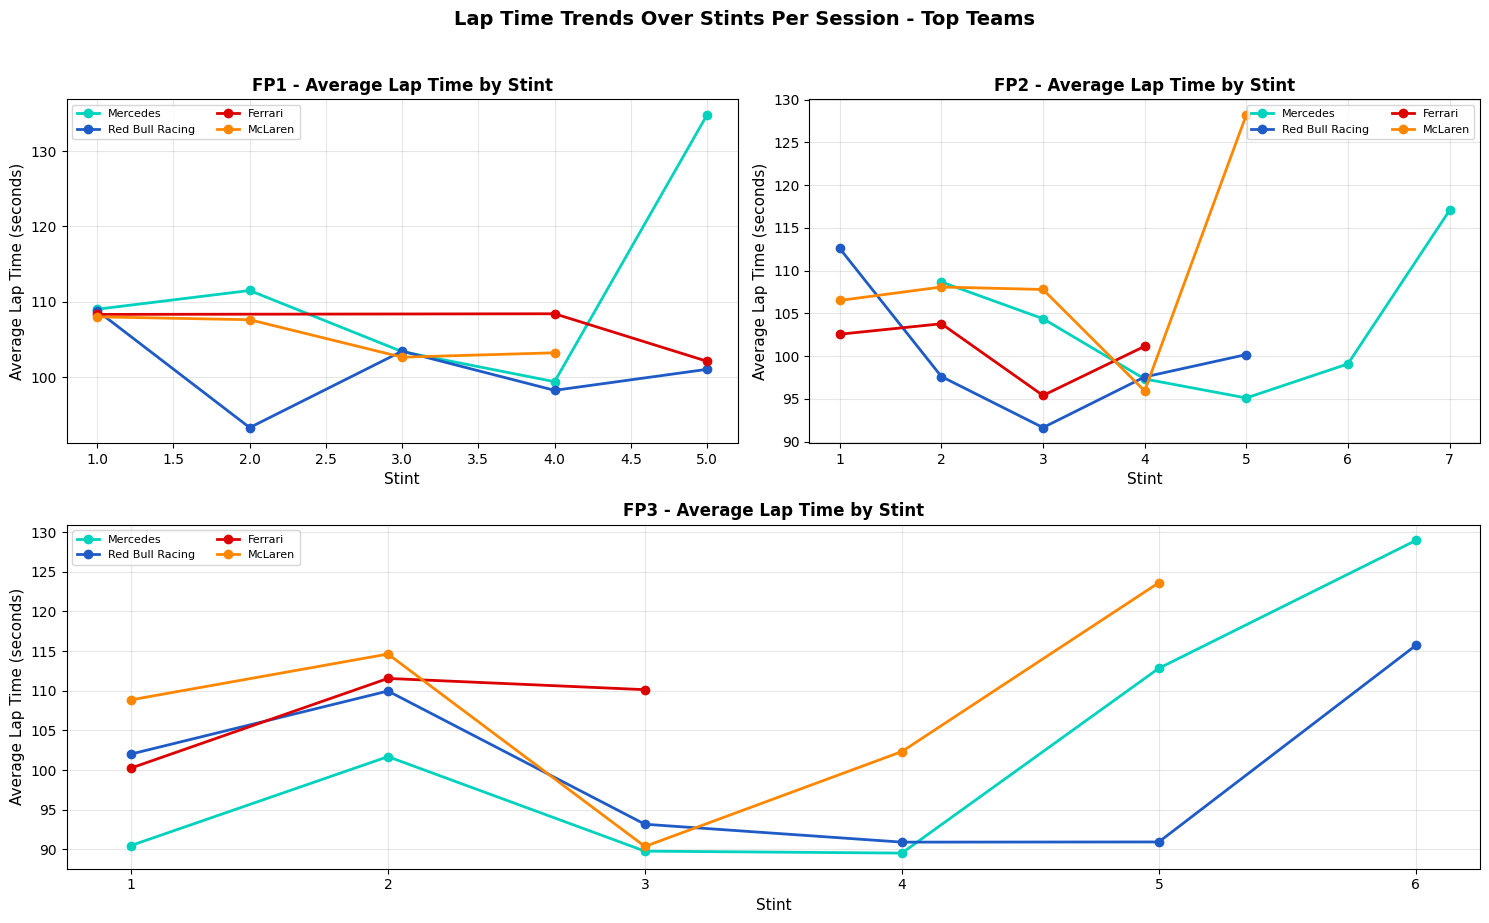

In [44]:
# Average lap time by stint for each session and top team
session_names = ['FP1', 'FP2', 'FP3']

layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(15, 9))

for session_name in session_names:
    ax = axes[session_name]
    session_df = top_teams_df[top_teams_df['Session'] == session_name].copy()

    for team in top_teams:
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'Stint' not in team_session.columns:
            continue

        team_session = team_session.dropna(subset=['Stint', 'LapTime'])
        if team_session.empty:
            continue

        stint_avg = (
            team_session.groupby('Stint', as_index=False)['LapTime']
            .mean()
            .sort_values('Stint')
)

        ax.plot(
            stint_avg['Stint'],
            stint_avg['LapTime'],
            marker='o',
            linewidth=2,
            markersize=6,
            color=team_palette.get(team, 'gray'),
            label=team
)

    ax.set_xlabel('Stint', fontsize=11)
    ax.set_ylabel('Average Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Average Lap Time by Stint', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle('Lap Time Trends Over Stints Per Session - Top Teams', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Speed Trap Trends by Session

Speed-trap traces add straight-line context to the lap-time story. Consistent top-end speed can indicate efficiency or deployment strength, but isolated slow points often come from traffic, lift-and-coast, pit-lane transitions, or non-push laps.

That makes SpeedST a useful feature, but not a standalone explanation for lap time. The strongest signal comes from how straight-line speed interacts with tyre state, session intent, and the rest of the lap.

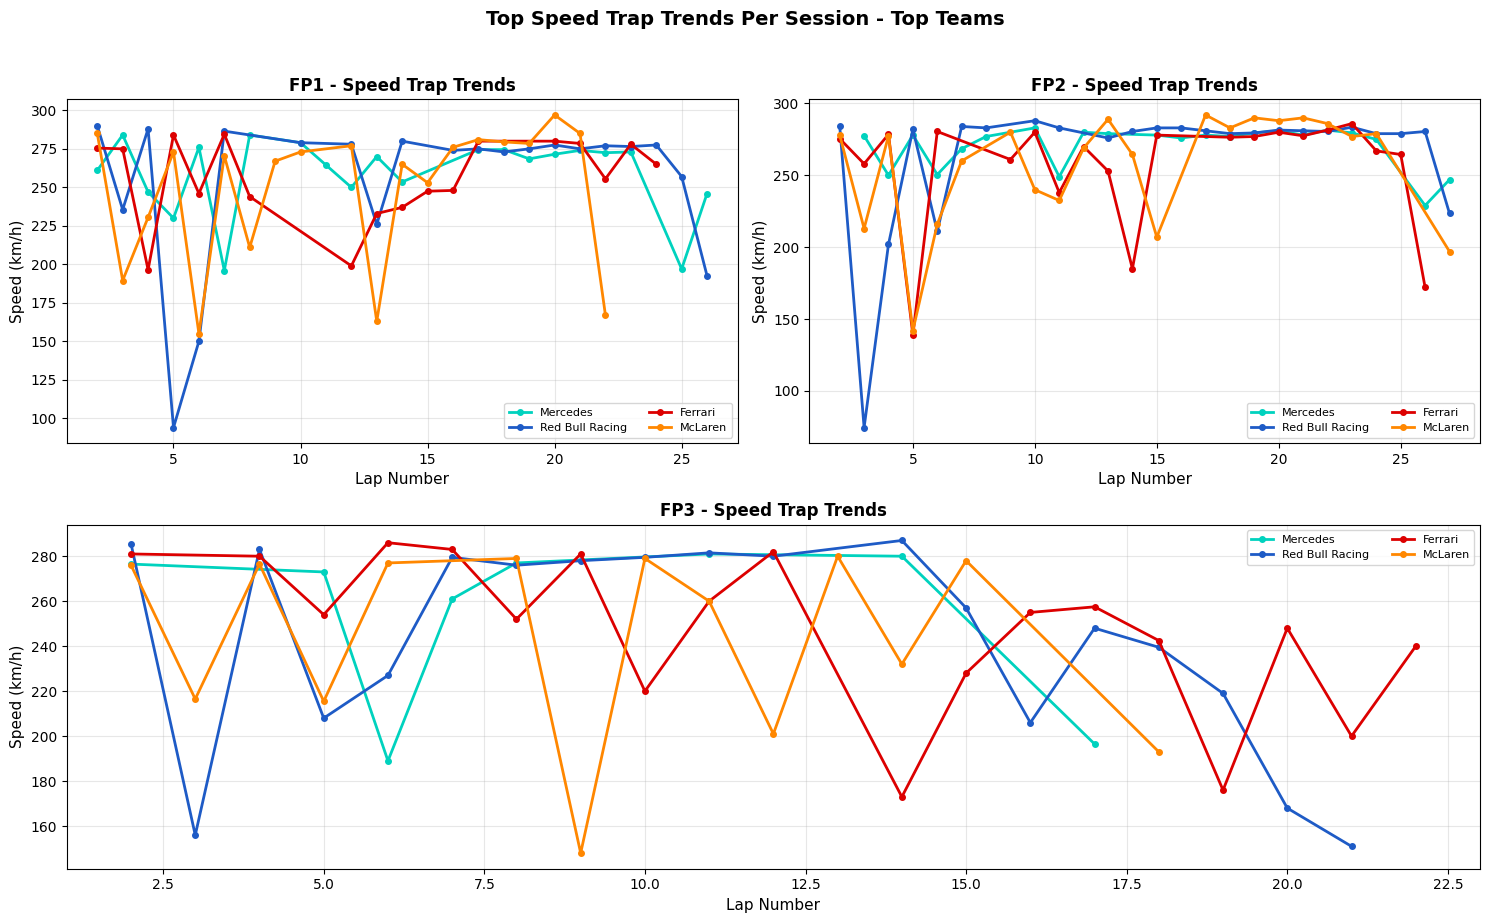

In [45]:
# Speed trap trends over sessions for top teams (median speed by lap number)
session_names = ['FP1', 'FP2', 'FP3']

layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(15, 9))

for session_name in session_names:
    ax = axes[session_name]
    session_df = top_teams_df[top_teams_df['Session'] == session_name].copy()

    for team in top_teams:
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'SpeedST' not in team_session.columns:
            continue

        speed_trend = (
            team_session.dropna(subset=['SpeedST'])
            .groupby('LapNumber', as_index=False)['SpeedST']
            .median()
            .sort_values('LapNumber')
)
        if speed_trend.empty:
            continue

        ax.plot(
            speed_trend['LapNumber'],
            speed_trend['SpeedST'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=team,
            color=team_palette.get(team, 'gray')
        )

    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'{session_name} - Speed Trap Trends', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle('Top Speed Trap Trends Per Session - Top Teams', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Telemetry and Track Map

This section compares the fastest available telemetry traces for the selected teams and overlays speed on the circuit map. The code intentionally skips missing or unreliable telemetry so the notebook can still run cleanly when a session pull does not return a full set of valid laps.

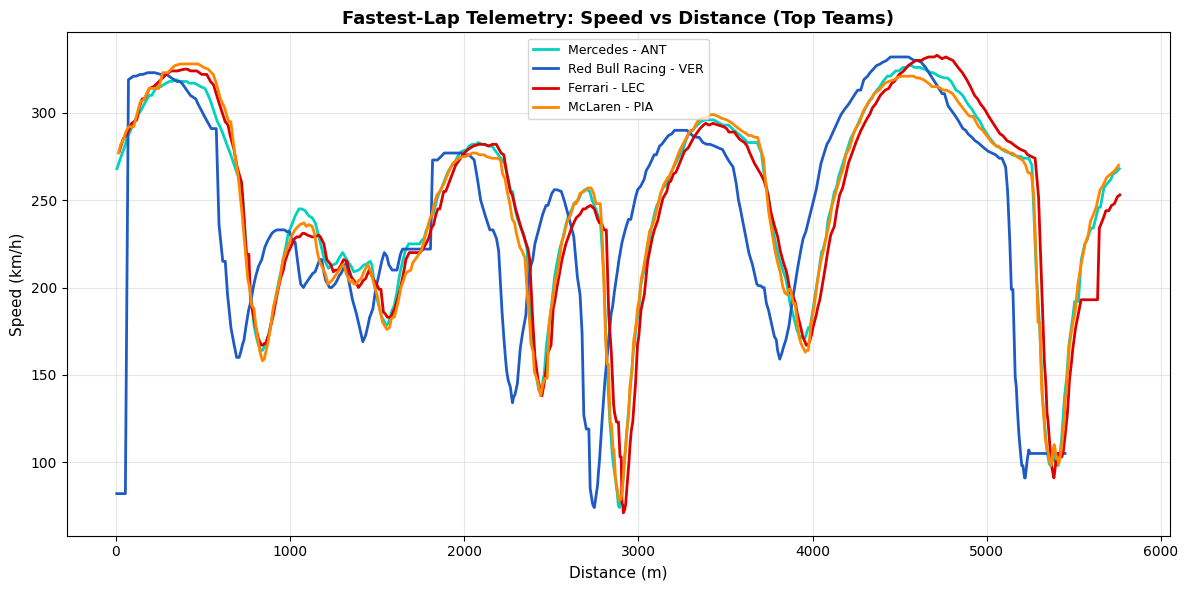

Telemetry fastest-lap summary:
           Team Driver Session  LapTimeSec
       Mercedes    ANT     FP3      89.362
        McLaren    PIA     FP2      90.133
        Ferrari    LEC     FP3      90.229
Red Bull Racing    VER     FP3      90.910


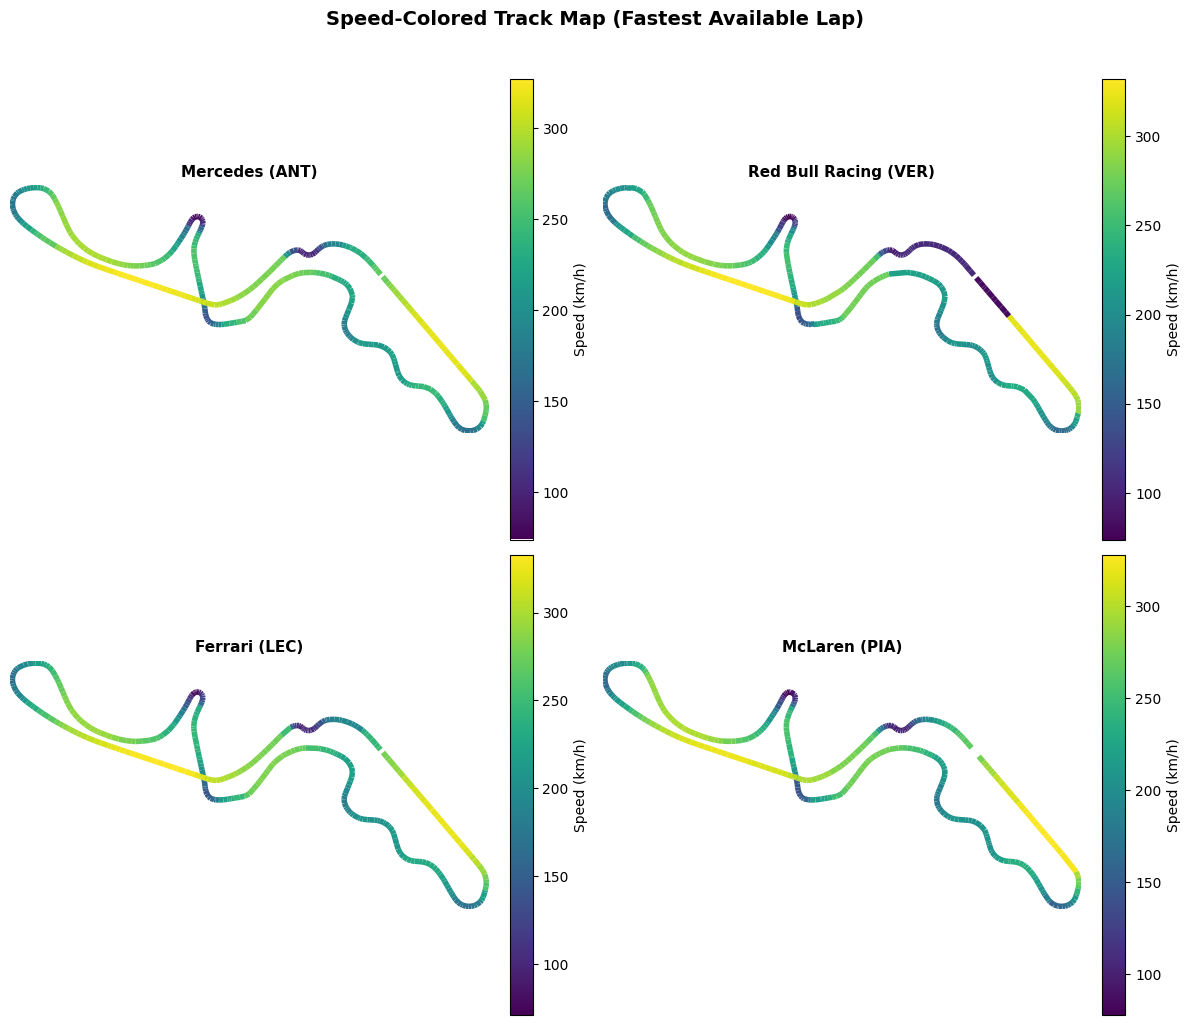

In [46]:
# Telemetry comparison and speed-colored track maps for fastest available laps
telemetry_sessions = ['FP1', 'FP2', 'FP3']

def lap_to_seconds(lap_time):
    return float(lap_time.total_seconds()) if pd.notna(lap_time) else np.nan

team_fastest = {}
for team in top_teams:
    candidate_laps = []

    for session_name in telemetry_sessions:
        session = sessions_by_name.get(session_name)
        if session is None:
            print(f"Session {session_name} not found in startup cache; skipping in telemetry block.")
            continue

        try:
            team_laps = session.laps.pick_teams(team).pick_quicklaps()
            if team_laps is None or len(team_laps) == 0:
                continue

            fastest = team_laps.pick_fastest()
            if fastest is not None and pd.notna(fastest['LapTime']):
                candidate_laps.append((session_name, fastest))
        except Exception as exc:
            print(f"Skipping {team} {session_name}: {exc}")

    if len(candidate_laps) == 0:
        print(f"No reliable telemetry lap found for {team} yet. Keeping logic for future reruns.")
        continue

    best_session, best_lap = min(candidate_laps, key=lambda item: item[1]['LapTime'])
    team_fastest[team] = {'session': best_session, 'lap': best_lap}

if len(team_fastest) == 0:
    print('No telemetry laps available to plot right now.')
else:
    # 1) Speed vs distance telemetry traces
    fig, ax = plt.subplots(figsize=(12, 6))
    summary_rows = []

    for team, payload in team_fastest.items():
        lap = payload['lap']
        session_name = payload['session']
        try:
            telemetry = lap.get_car_data().add_distance()
            ax.plot(
                telemetry['Distance'],
                telemetry['Speed'],
                color=team_palette.get(team, 'gray'),
                linewidth=2,
                label=f"{team} - {lap['Driver']}"
            )
            summary_rows.append({
                'Team': team,
                'Driver': lap['Driver'],
                'Session': session_name,
                'LapTimeSec': lap_to_seconds(lap['LapTime'])
            })
        except Exception as exc:
            print(f"Telemetry plot skipped for {team}: {exc}")

    ax.set_title('Fastest-Lap Telemetry: Speed vs Distance (Top Teams)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Distance (m)', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    if summary_rows:
        telemetry_summary = pd.DataFrame(summary_rows).sort_values('LapTimeSec').reset_index(drop=True)
        print('Telemetry fastest-lap summary:')
        print(telemetry_summary.to_string(index=False))

    # 2) Track map colored by speed for each team
    map_teams = []
    map_data = {}
    for team, payload in team_fastest.items():
        lap = payload['lap']
        try:
            car = lap.get_car_data()[['Time', 'Speed']].copy().sort_values('Time')
            pos = lap.get_pos_data()[['Time', 'X', 'Y']].copy().sort_values('Time')

            if car.empty or pos.empty:
                print(f"Track map skipped for {team}: empty telemetry frames")
                continue

            merged = pd.merge_asof(pos, car, on='Time', direction='nearest')
            merged = merged.dropna(subset=['X', 'Y', 'Speed'])
            if len(merged) < 2:
                print(f"Track map skipped for {team}: insufficient merged telemetry points")
                continue

            map_teams.append(team)
            map_data[team] = {
                'x': merged['X'].to_numpy(),
                'y': merged['Y'].to_numpy(),
                'speed': merged['Speed'].to_numpy(),
                'driver': lap['Driver']
            }
        except Exception as exc:
            print(f"Track map skipped for {team}: {exc}")

    if len(map_teams) == 0:
        print('No track-map telemetry available to draw right now.')
    else:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes_flat = axes.flatten()

        for idx, team in enumerate(map_teams):
            if idx >= 4:
                break

            ax = axes_flat[idx]
            x = map_data[team]['x']
            y = map_data[team]['y']
            speed = map_data[team]['speed']
            driver = map_data[team]['driver']

            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            norm = plt.Normalize(speed.min(), speed.max())
            lc = LineCollection(segments, cmap='viridis', norm=norm)
            lc.set_array(speed[:-1])
            lc.set_linewidth(4)

            ax.add_collection(lc)
            ax.set_aspect('equal', 'box')
            ax.set_xlim(x.min() - 100, x.max() + 100)
            ax.set_ylim(y.min() - 100, y.max() + 100)
            ax.axis('off')
            ax.set_title(f"{team} ({driver})", fontsize=11, fontweight='bold')

            cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Speed (km/h)')

        plt.suptitle('Speed-Colored Track Map (Fastest Available Lap)', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

### Tyre Compound Performance

Compound-level distributions show whether pace and consistency change when teams switch between SOFT, MEDIUM, and HARD tyres. Even when average lap time is similar, the spread can differ sharply because warm-up behavior, push-lap intent, and degradation profiles are not the same across compounds.

SOFT laps often contain both the strongest single-lap pace and some of the noisiest practice examples. That is why this notebook uses visual diagnostics and not just simple mean comparisons.

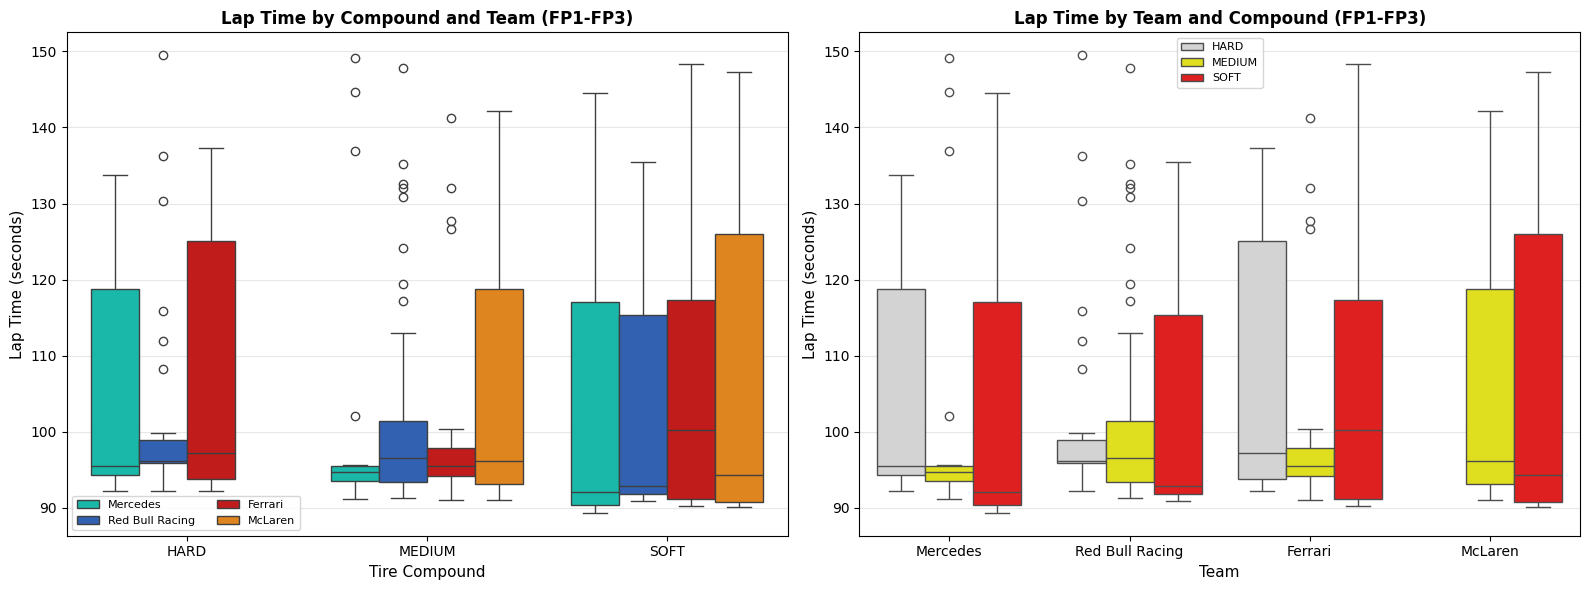

Average Lap Time by Team and Compound:
                             mean     std  count
Team            Compound                        
Ferrari         HARD      108.313  18.494     13
                MEDIUM    101.383  14.705     23
                SOFT      106.466  18.180     53
McLaren         MEDIUM    104.615  15.919     36
                SOFT      107.303  19.162     41
Mercedes        HARD      104.974  15.764     20
                MEDIUM    100.413  16.930     24
                SOFT      104.150  19.135     37
Red Bull Racing HARD      101.121  12.899     35
                MEDIUM    102.061  14.160     46
                SOFT      103.993  15.334     18


In [47]:
# Tire compound performance across top teams
practice_sessions = ['FP1', 'FP2', 'FP3']
practice_df = top_teams_df[top_teams_df['Session'].isin(practice_sessions)].copy()

tire_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'lightgrey'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lap time by compound, segmented by team
compound_order = sorted([c for c in practice_df['Compound'].dropna().unique()])
sns.boxplot(
    data=practice_df[practice_df['Compound'].notna()],
    x='Compound',
    y='LapTime',
    hue='Team',
    order=compound_order,
    hue_order=top_teams,
    palette=team_palette,
    ax=axes[0]
)
axes[0].set_xlabel('Tire Compound', fontsize=11)
axes[0].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[0].set_title('Lap Time by Compound and Team (FP1-FP3)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend(fontsize=8, ncol=2)

# Lap time by team, segmented by compound
team_order = [t for t in top_teams if t in practice_df['Team'].unique()]
sns.boxplot(
    data=practice_df[practice_df['Compound'].notna()],
    x='Team',
    y='LapTime',
    hue='Compound',
    order=team_order,
    hue_order=compound_order,
    palette={c: tire_colors.get(c, 'gray') for c in compound_order},
    ax=axes[1]
)
axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time by Team and Compound (FP1-FP3)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Average Lap Time by Team and Compound:')
print(
    practice_df.groupby(['Team', 'Compound'])['LapTime']
    .agg(['mean', 'std', 'count'])
    .round(3)
    .sort_index()
)

## Machine Learning Analysis

This section builds supervised regression models to predict top-team lap time from lap context, tyre state, straight-line speed, and driver-team identifiers. Performance is evaluated with a baseline benchmark plus MAE, RMSE, and R2 on a held-out test split.

### Qualifying Model Pipeline

The pipeline keeps preprocessing and model fitting in one reproducible object. Numeric features are passed through directly, categorical variables are one-hot encoded, and ensemble regressors are trained on a filtered qualifying-oriented subset of the practice data.

The current implementation focuses the training set on SOFT-tyre laps marked as fresh-tyre runs, then rebalances session representation before fitting the models.

In [48]:
def qualifying_model_pipeline():
    print("Starting model pipeline")

    # Use top-team data and keep columns needed for modeling
    model_df = top_teams_df.copy()

    # Reduce extreme outliers that hurt variance-based metrics like R^2
    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    # Train only on soft-compound laps
    required_filter_cols = ['Compound']
    missing_filter_cols = [col for col in required_filter_cols if col not in model_df.columns]
    if missing_filter_cols:
        raise KeyError(f"Missing required filter column(s): {missing_filter_cols}")

    soft_mask = model_df['Compound'].astype(str).str.upper() == 'SOFT'
    fresh_mask = model_df['FreshTyre'].astype(str).str.lower().isin(['true', '1', 'yes'])
    model_df = model_df[soft_mask & fresh_mask].copy()
    print(f"Rows after SOFT + FreshTyre filter: {len(model_df)}")

    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column: Session")

    # Define features and target
    numeric_features = ['LapNumber', 'TyreLife', 'Stint', 'SpeedST']
    categorical_features = ['Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
    features = numeric_features + categorical_features
    target = 'LapTime'

    # Keep rows where required columns exist and are non-null
    required_cols = features + [target]
    model_df = model_df[required_cols].dropna().copy()

    print(f"Rows after modeling filters: {len(model_df)}")

    # Split into features and target
    X = model_df[features].copy()
    y = model_df[target].copy()

    # One-hot encode categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

    print("Preprocessing pipeline created")

    # Use stratification only when every session has enough examples
    stratify_series = None
    session_counts = X['Session'].value_counts()
    if len(session_counts) > 1 and session_counts.min() >= 2:
        stratify_series = X['Session']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=324,
        stratify=stratify_series
    )

    # Baseline model for context
    baseline = DummyRegressor(strategy='mean')
    baseline.fit(X_train[numeric_features], y_train)
    baseline_predictions = baseline.predict(X_test[numeric_features])
    baseline_r2 = r2_score(y_test, baseline_predictions)

    # Create model pipelines
    rf_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('rf_regressor', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=324))
    ])

    gb_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('gb_regressor', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=324))
    ])

    xgb_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('xgb_regressor', XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=324, verbosity=0))
    ])

    # Train model and make predictions
    print("Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print("Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print("Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Calculate model metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # Driver-level diagnostics: this helps choose the best model per driver, not only globally.
    driver_eval_df = X_test[['Driver', 'Team', 'Session']].copy().reset_index(drop=True)
    driver_eval_df['ActualLapTime'] = y_test.reset_index(drop=True)
    driver_eval_df['RF_Pred'] = rf_predictions
    driver_eval_df['GB_Pred'] = gb_predictions
    driver_eval_df['XGB_Pred'] = xgb_predictions
    driver_eval_df['RF_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['RF_Pred']).abs()
    driver_eval_df['GB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['GB_Pred']).abs()
    driver_eval_df['XGB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['XGB_Pred']).abs()

    q_driver_mae = (
        driver_eval_df
        .groupby('Driver', as_index=False)[['RF_AbsErr', 'GB_AbsErr', 'XGB_AbsErr']]
        .mean()
        .rename(columns={
            'RF_AbsErr': 'RF_MAE',
            'GB_AbsErr': 'GB_MAE',
            'XGB_AbsErr': 'XGB_MAE'
        })
    )

    q_driver_mae['BestModel'] = q_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].idxmin(axis=1).map({
        'RF_MAE': 'Random Forest Regression',
        'GB_MAE': 'Gradient Boosting Regression',
        'XGB_MAE': 'XGBoost Regression'
    })
    q_driver_mae['BestMAE'] = q_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].min(axis=1)
    q_driver_mae = q_driver_mae.sort_values('BestMAE').reset_index(drop=True)

    print("Model training completed")

    return {
        'q_model_df': model_df,
        'q_features': features,
        'q_X_train': X_train,
        'q_X_test': X_test,
        'q_y_train': y_train,
        'q_y_test': y_test,
        'q_baseline_r2': baseline_r2,
        'q_rf_model': rf_model,
        'q_rf_predictions': rf_predictions,
        'q_rf_mae': rf_mae,
        'q_rf_rmse': rf_rmse,
        'q_rf_r2': rf_r2,
        'q_gb_model': gb_model,
        'q_gb_predictions': gb_predictions,
        'q_gb_mae': gb_mae,
        'q_gb_rmse': gb_rmse,
        'q_gb_r2': gb_r2,
        'q_xgb_model': xgb_model,
        'q_xgb_predictions': xgb_predictions,
        'q_xgb_mae': xgb_mae,
        'q_xgb_rmse': xgb_rmse,
        'q_xgb_r2': xgb_r2,
        'q_driver_eval_df': driver_eval_df,
        'q_driver_mae': q_driver_mae
    }

In [49]:
# Run the model pipeline
model_results = qualifying_model_pipeline()

# Extract results
q_model_df = model_results['q_model_df']
q_features = model_results['q_features']
q_X_train = model_results['q_X_train']
q_X_test = model_results['q_X_test']
q_y_train = model_results['q_y_train']
q_y_test = model_results['q_y_test']
q_baseline_r2 = model_results['q_baseline_r2']
q_rf_model = model_results['q_rf_model']
q_rf_predictions = model_results['q_rf_predictions']
q_rf_mae = model_results['q_rf_mae']
q_rf_rmse = model_results['q_rf_rmse']
q_rf_r2 = model_results['q_rf_r2']
q_gb_model = model_results['q_gb_model']
q_gb_predictions = model_results['q_gb_predictions']
q_gb_mae = model_results['q_gb_mae']
q_gb_rmse = model_results['q_gb_rmse']
q_gb_r2 = model_results['q_gb_r2']
q_xgb_model = model_results['q_xgb_model']
q_xgb_predictions = model_results['q_xgb_predictions']
q_xgb_mae = model_results['q_xgb_mae']
q_xgb_rmse = model_results['q_xgb_rmse']
q_xgb_r2 = model_results['q_xgb_r2']
q_driver_eval_df = model_results['q_driver_eval_df']
q_driver_mae = model_results['q_driver_mae']

Starting model pipeline
Rows after SOFT + FreshTyre filter: 82
Rows after modeling filters: 82
Preprocessing pipeline created
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [50]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Random Forest Regression', 'Gradient Boosting Regression' , 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [q_rf_mae, q_gb_mae, q_xgb_mae],
    'Root Absolute Error (RMSE)': [q_rf_rmse, q_gb_rmse, q_xgb_rmse],
    'R² Score': [q_rf_r2, q_gb_r2, q_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print(f"Baseline R² (mean predictor): {q_baseline_r2:.3f}")
print("Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Determine the best global model for reference.
if q_rf_r2 > q_gb_r2 and q_rf_r2 > q_xgb_r2:
    best_model = 'Random Forest Regression'
    print(f"\nBest performing global model for qualifying: {best_model}")
elif q_rf_r2 < q_gb_r2 and q_gb_r2 > q_xgb_r2:
    best_model = 'Gradient Boosting Regression'
    print(f"\nBest performing global model for qualifying: {best_model}")
elif q_xgb_r2 > q_rf_r2 and q_xgb_r2 > q_gb_r2:
    best_model = 'XGBoost Regression'
    print(f"\nBest performing global model for qualifying: {best_model}")
else:
    best_model = 'Tie'
    print("\nGlobal models have very similar R². No clear single best model.")

# Driver-level best model is often different from the global best model.
print("\nDriver-level best validation model (lower MAE is better):")
print(
    q_driver_mae[['Driver', 'RF_MAE', 'GB_MAE', 'XGB_MAE', 'BestModel', 'BestMAE']]
    .sort_values('BestMAE')
    .to_string(index=False)
)

Baseline R² (mean predictor): -0.001
Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
    Random Forest Regression                 3.648 sec                  6.619 sec    0.822
Gradient Boosting Regression                 4.008 sec                  7.036 sec    0.799
          XGBoost Regression                 3.565 sec                  6.393 sec    0.834

Best performing global model for qualifying: XGBoost Regression

Driver-level best validation model (lower MAE is better):
Driver    RF_MAE    GB_MAE   XGB_MAE                    BestModel   BestMAE
   RUS  0.491848  0.214259  0.100002           XGBoost Regression  0.100002
   PIA  0.272456  0.528642  2.685024     Random Forest Regression  0.272456
   VER  0.326221  3.209721  0.336536     Random Forest Regression  0.326221
   LEC  3.372458  1.492593  1.885105 Gradient Boosting Regression  1.492593
   HAM  1.661583  2.659050  1.560778           XGBoost Regression  1

#### Qualifying Model Performance Visualizations

The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

##### Metric Comparison

The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.

Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

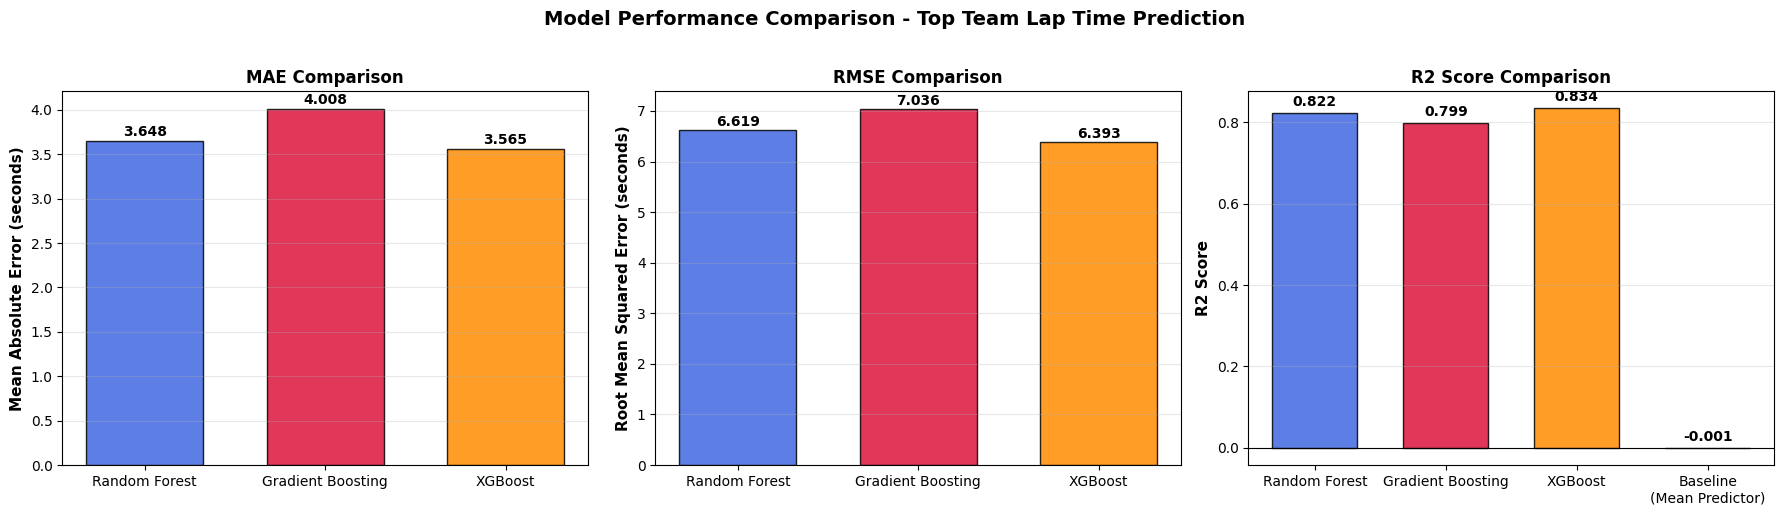

In [51]:
# Model Comparison for qualifying prediction
models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Baseline\n(Mean Predictor)']
mae_scores = [q_rf_mae, q_gb_mae, q_xgb_mae, None]
rmse_scores = [q_rf_rmse, q_gb_rmse, q_xgb_rmse, None]
r2_scores = [q_rf_r2, q_gb_r2, q_xgb_r2, q_baseline_r2]

# Compare all trained models directly; keep baseline only for R² context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_models = models[:3]
bar_colors = ['royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(bar_models, mae_scores[:3], color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores[:3]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(bar_models, rmse_scores[:3], color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores[:3]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison (includes baseline)
colors_r2 = ['royalblue', 'crimson', 'darkorange', 'lightgray']
axes[2].bar(models, r2_scores, color=colors_r2, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - Top Team Lap Time Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

##### Residual Diagnostics

Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

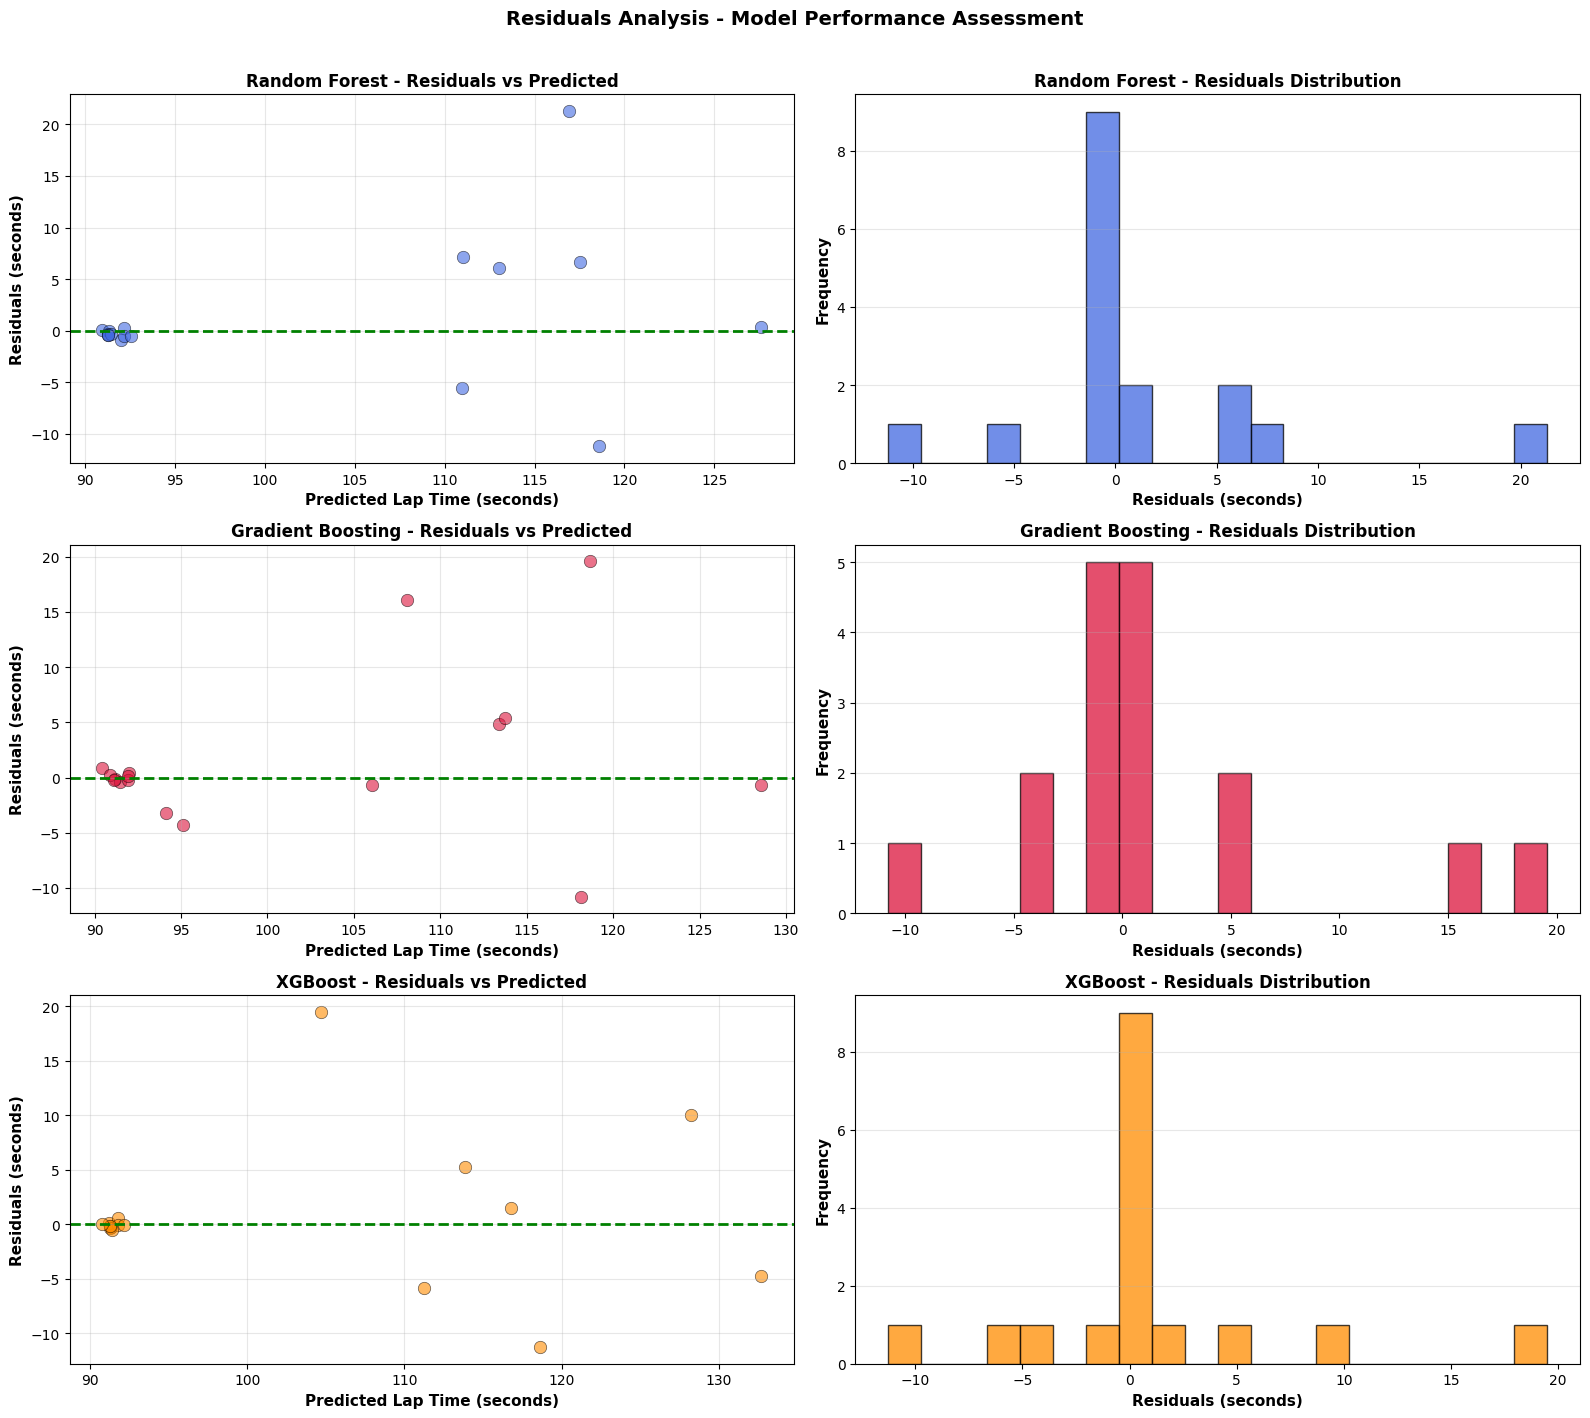

Random Forest - Mean Residuals: 1.2730, Std Dev: 6.6957
Gradient Boosting - Mean Residuals: 1.5767, Std Dev: 7.0677
XGBoost - Mean Residuals: 0.7891, Std Dev: 6.5391


In [52]:
# Residuals Analysis
rf_residuals = q_y_test - q_rf_predictions
gb_residuals = q_y_test - q_gb_predictions
xgb_residuals = q_y_test - q_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(q_rf_predictions, rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(q_gb_predictions, gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(q_xgb_predictions, xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {rf_residuals.mean():.4f}, Std Dev: {rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {gb_residuals.mean():.4f}, Std Dev: {gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {xgb_residuals.mean():.4f}, Std Dev: {xgb_residuals.std():.4f}")

##### Actual vs Predicted Fit

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

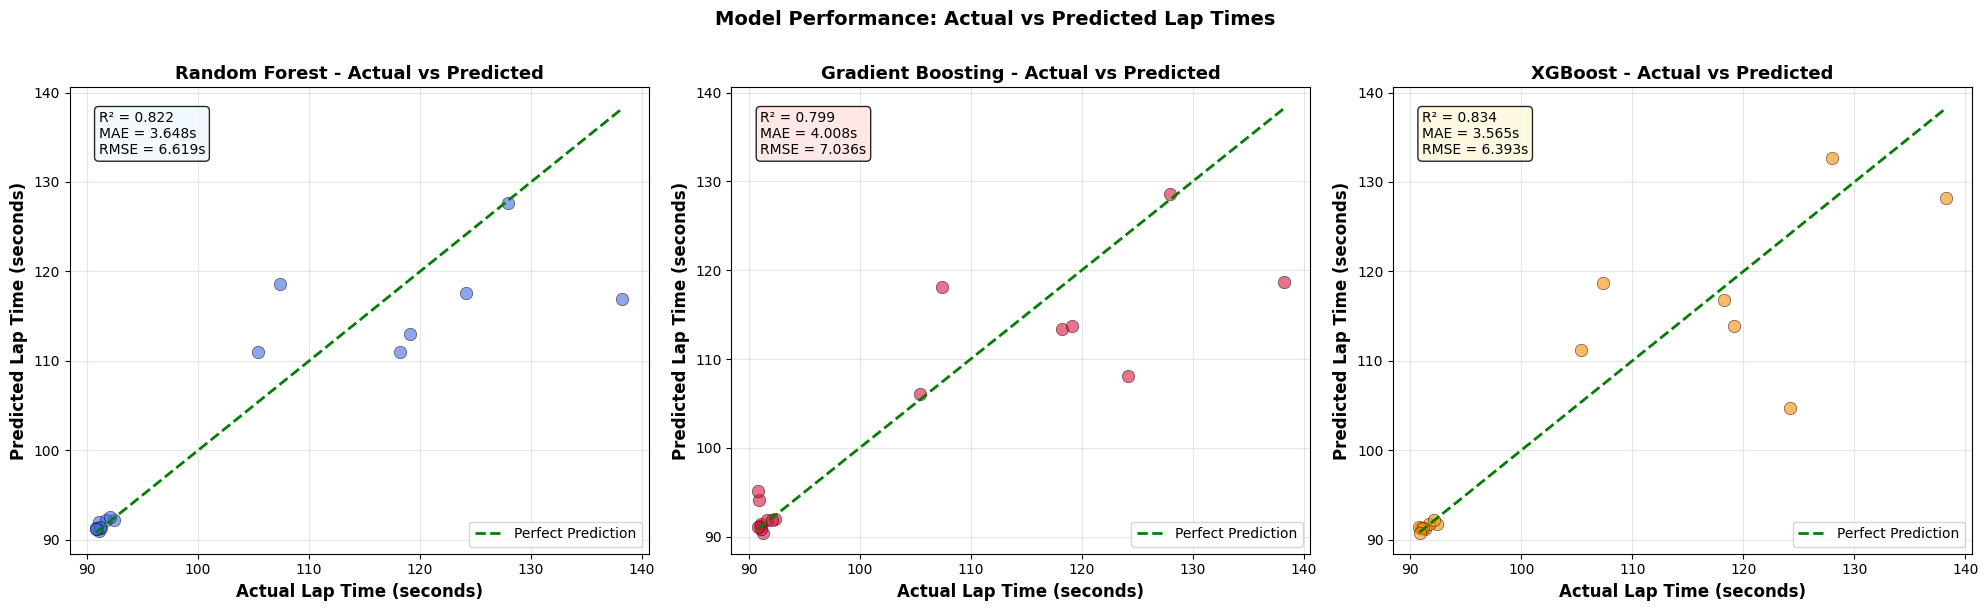

In [53]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(q_y_test, q_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(
    0.05, 0.95,
    f'R² = {q_rf_r2:.3f}\nMAE = {q_rf_mae:.3f}s\nRMSE = {q_rf_rmse:.3f}s',
    transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
 )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(q_y_test, q_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(
    0.05, 0.95,
    f'R² = {q_gb_r2:.3f}\nMAE = {q_gb_mae:.3f}s\nRMSE = {q_gb_rmse:.3f}s',
    transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.85)
 )

# XGBoost: Actual vs Predicted
axes[2].scatter(q_y_test, q_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(
    0.05, 0.95,
    f'R² = {q_xgb_r2:.3f}\nMAE = {q_xgb_mae:.3f}s\nRMSE = {q_xgb_rmse:.3f}s',
    transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='cornsilk', alpha=0.85)
 )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Tyre Degradation Model Pipeline

In [54]:
def tyredeg_model_pipeline():
    print("Starting tyre degradation model pipeline")

    # Use top-team data and keep columns needed for modeling
    model_df = top_teams_df.copy()

    # Reduce extreme outliers that hurt variance-based metrics like R^2
    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    # Validate required columns for tyre degradation analysis
    required_filter_cols = ['Compound', 'TyreLife']
    missing_filter_cols = [col for col in required_filter_cols if col not in model_df.columns]
    if missing_filter_cols:
        raise KeyError(f"Missing required filter column(s): {missing_filter_cols}")

    # Include ALL tyre compounds to study degradation patterns across compound types
    valid_compounds = ['SOFT', 'MEDIUM', 'HARD']
    compound_mask = model_df['Compound'].astype(str).str.upper().isin(valid_compounds)
    model_df = model_df[compound_mask].copy()
    print(f"Rows after compound filter (SOFT, MEDIUM, HARD): {len(model_df)}")
    print("Compound distribution:")
    print(model_df['Compound'].value_counts().to_string())

    # Oversample minority sessions to balance representation
    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column for oversampling: Session")

    session_counts_filtered = model_df['Session'].value_counts()
    if len(session_counts_filtered) > 1 and session_counts_filtered.min() > 0:
        target_size = session_counts_filtered.max()
        oversampled_groups = []

        for session_name, session_group in model_df.groupby('Session', dropna=False):
            if len(session_group) < target_size:
                session_group = resample(
                    session_group,
                    replace=True,
                    n_samples=target_size,
                    random_state=324
                )
            oversampled_groups.append(session_group)

        model_df = pd.concat(oversampled_groups, ignore_index=True)
        model_df = model_df.sample(frac=1, random_state=324).reset_index(drop=True)
        print(f"Rows after session oversampling: {len(model_df)}")
        print("Session distribution after oversampling:")
        print(model_df['Session'].value_counts().to_string())
    else:
        print("Session oversampling skipped (not enough session imbalance or only one session present).")

    # Define features and target - TyreLife is key for degradation modeling
    numeric_features = ['LapNumber', 'TyreLife', 'Stint', 'SpeedST', 'TrackStatus']
    categorical_features = ['Compound', 'Driver', 'Team', 'Session', 'FreshTyre']
    features = numeric_features + categorical_features
    target = 'LapTime'

    # Keep rows where required columns exist and are non-null
    required_cols = features + [target]
    model_df = model_df[required_cols].dropna().copy()

    print(f"Rows after modeling filters: {len(model_df)}")
    print(f"TyreLife range: {model_df['TyreLife'].min()} to {model_df['TyreLife'].max()}")

    # Split into features and target
    X = model_df[features].copy()
    y = model_df[target].copy()

    # One-hot encode categorical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

    print("Preprocessing pipeline created")

    # Use stratification only when every session has enough examples
    stratify_series = None
    session_counts = X['Session'].value_counts()
    if len(session_counts) > 1 and session_counts.min() >= 2:
        stratify_series = X['Session']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=324,
                                                        stratify=stratify_series)

    # Baseline model for context
    baseline = DummyRegressor(strategy='mean')
    baseline.fit(X_train[numeric_features], y_train)
    baseline_predictions = baseline.predict(X_test[numeric_features])
    baseline_r2 = r2_score(y_test, baseline_predictions)

    # Create model pipelines
    rf_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('rf_regressor', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=324))
    ])

    gb_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('gb_regressor', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=324))
    ])

    xgb_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('xgb_regressor', XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=324, verbosity=0))
    ])

    # Train model and make predictions
    print(f"Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print(f"Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print(f"Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Calculate model metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    print("Model training completed")

    return {
        't_model_df': model_df,
        't_features': features,
        't_X_train': X_train,
        't_X_test': X_test,
        't_y_train': y_train,
        't_y_test': y_test,
        't_baseline_r2': baseline_r2,
        't_rf_model': rf_model,
        't_rf_predictions': rf_predictions,
        't_rf_mae': rf_mae,
        't_rf_rmse': rf_rmse,
        't_rf_r2': rf_r2,
        't_gb_model': gb_model,
        't_gb_predictions': gb_predictions,
        't_gb_mae': gb_mae,
        't_gb_rmse': gb_rmse,
        't_gb_r2': gb_r2,
        't_xgb_model': xgb_model,
        't_xgb_predictions': xgb_predictions,
        't_xgb_mae': xgb_mae,
        't_xgb_rmse': xgb_rmse,
        't_xgb_r2': xgb_r2
    }

In [55]:
# Run the model pipeline
model_results = tyredeg_model_pipeline()

# Extract results
t_model_df = model_results['t_model_df']
t_features = model_results['t_features']
t_X_train = model_results['t_X_train']
t_X_test = model_results['t_X_test']
t_y_train = model_results['t_y_train']
t_y_test = model_results['t_y_test']
t_baseline_r2 = model_results['t_baseline_r2']
t_rf_model = model_results['t_rf_model']
t_rf_predictions = model_results['t_rf_predictions']
t_rf_mae = model_results['t_rf_mae']
t_rf_rmse = model_results['t_rf_rmse']
t_rf_r2 = model_results['t_rf_r2']
t_gb_model = model_results['t_gb_model']
t_gb_predictions = model_results['t_gb_predictions']
t_gb_mae = model_results['t_gb_mae']
t_gb_rmse = model_results['t_gb_rmse']
t_gb_r2 = model_results['t_gb_r2']
t_xgb_model = model_results['t_xgb_model']
t_xgb_predictions = model_results['t_xgb_predictions']
t_xgb_mae = model_results['t_xgb_mae']
t_xgb_rmse = model_results['t_xgb_rmse']
t_xgb_r2 = model_results['t_xgb_r2']

Starting tyre degradation model pipeline
Rows after compound filter (SOFT, MEDIUM, HARD): 310
Compound distribution:
Compound
MEDIUM    124
SOFT      119
HARD       67
Rows after session oversampling: 369
Session distribution after oversampling:
Session
FP3    123
FP1    123
FP2    123
Rows after modeling filters: 369
TyreLife range: 2.0 to 22.0
Preprocessing pipeline created
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [56]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Random Forest Regression', 'Gradient Boosting Regression' , 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [t_rf_mae, t_gb_mae, t_xgb_mae],
    'Root Absolute Error (RMSE)': [t_rf_rmse, t_gb_rmse, t_xgb_rmse],
    'R² Score': [t_rf_r2, t_gb_r2, t_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print(f"Baseline R² (mean predictor): {t_baseline_r2:.3f}")
print("Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Determine the best tyre degradation model.
if t_rf_r2 > t_gb_r2 and t_rf_r2 > t_xgb_r2:
    best_model = 'Random Forest Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_rf_r2 < t_gb_r2 and t_gb_r2 > t_xgb_r2:
    best_model = 'Gradient Boosting Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_xgb_r2 > t_rf_r2 and t_xgb_r2 > t_gb_r2:
    best_model = 'XGBoost Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
else:
    print("\nModels have the same R² score. No clear best model.")

Baseline R² (mean predictor): -0.009
Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
    Random Forest Regression                 3.125 sec                  6.362 sec    0.786
Gradient Boosting Regression                 3.136 sec                  6.420 sec    0.782
          XGBoost Regression                 2.739 sec                  6.602 sec    0.770

Best performing model for predicting tyre degradation: Random Forest Regression


#### Tyre Degradation Model Performance Visualizations

The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

##### Metric Comparison

The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.

Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

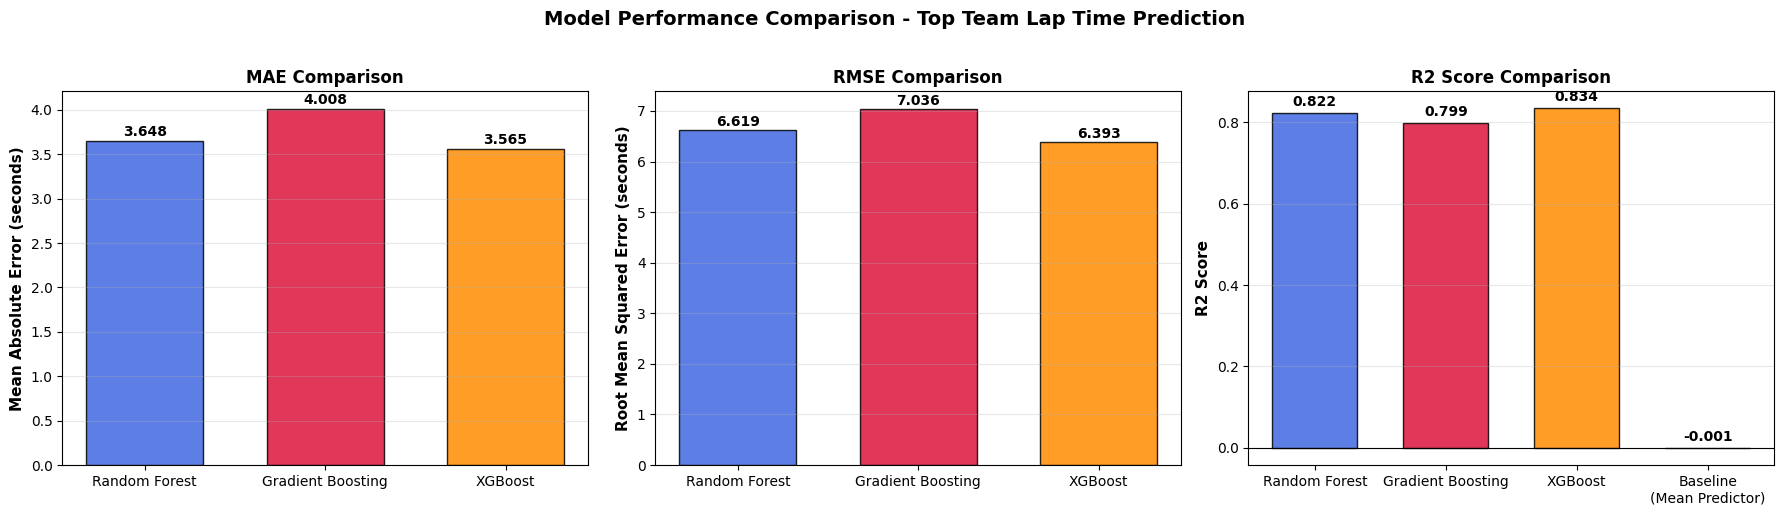

In [57]:
# Model Comparison for qualifying prediction
models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Baseline\n(Mean Predictor)']
mae_scores = [q_rf_mae, q_gb_mae, q_xgb_mae, None]
rmse_scores = [q_rf_rmse, q_gb_rmse, q_xgb_rmse, None]
r2_scores = [q_rf_r2, q_gb_r2, q_xgb_r2, q_baseline_r2]

# Compare all trained models directly; keep baseline only for R² context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_models = models[:3]
bar_colors = ['royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(bar_models, mae_scores[:3], color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores[:3]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(bar_models, rmse_scores[:3], color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores[:3]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison (includes baseline)
colors_r2 = ['royalblue', 'crimson', 'darkorange', 'lightgray']
axes[2].bar(models, r2_scores, color=colors_r2, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - Top Team Lap Time Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

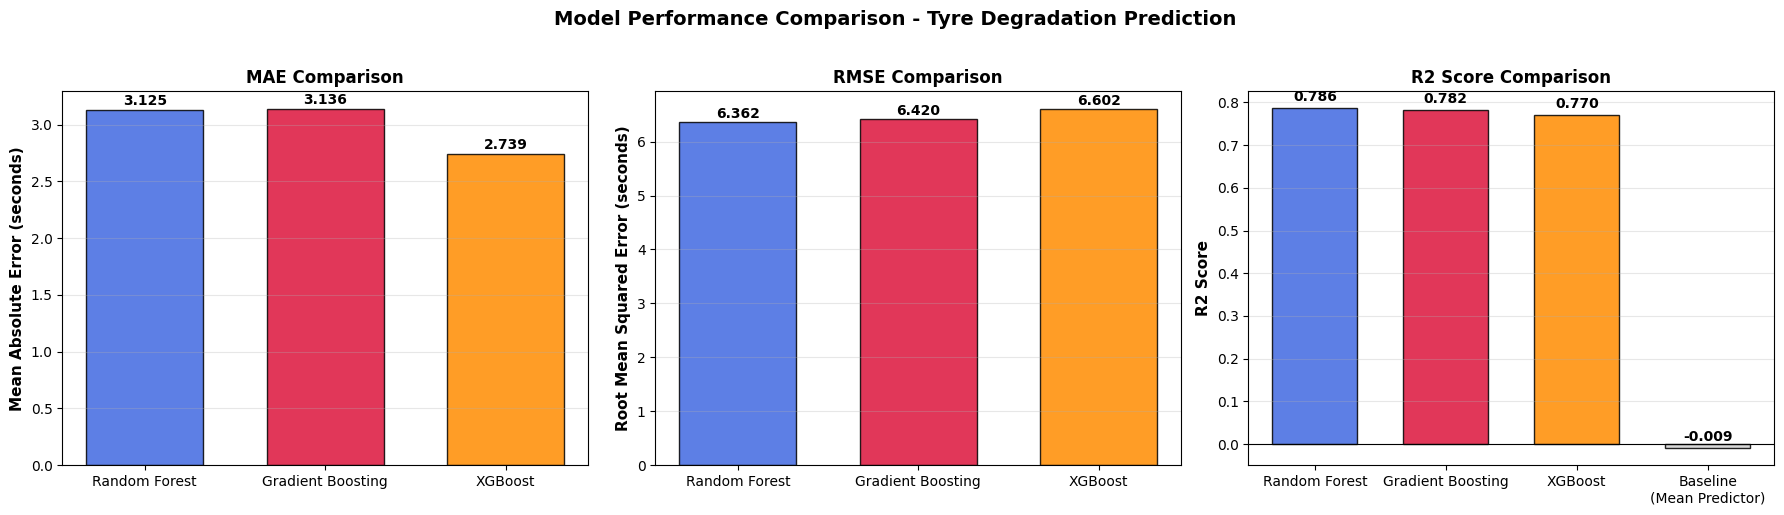

In [58]:
# Model Comparison for tyre degradation prediction
models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Baseline\n(Mean Predictor)']
mae_scores = [t_rf_mae, t_gb_mae, t_xgb_mae, None]
rmse_scores = [t_rf_rmse, t_gb_rmse, t_xgb_rmse, None]
r2_scores = [t_rf_r2, t_gb_r2, t_xgb_r2, t_baseline_r2]

# Compare all trained models directly; keep baseline only for R² context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_models = models[:3]
bar_colors = ['royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(bar_models, mae_scores[:3], color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores[:3]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(bar_models, rmse_scores[:3], color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores[:3]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison (includes baseline)
colors_r2 = ['royalblue', 'crimson', 'darkorange', 'lightgray']
axes[2].bar(models, r2_scores, color=colors_r2, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - Tyre Degradation Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Residual Diagnostics

Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

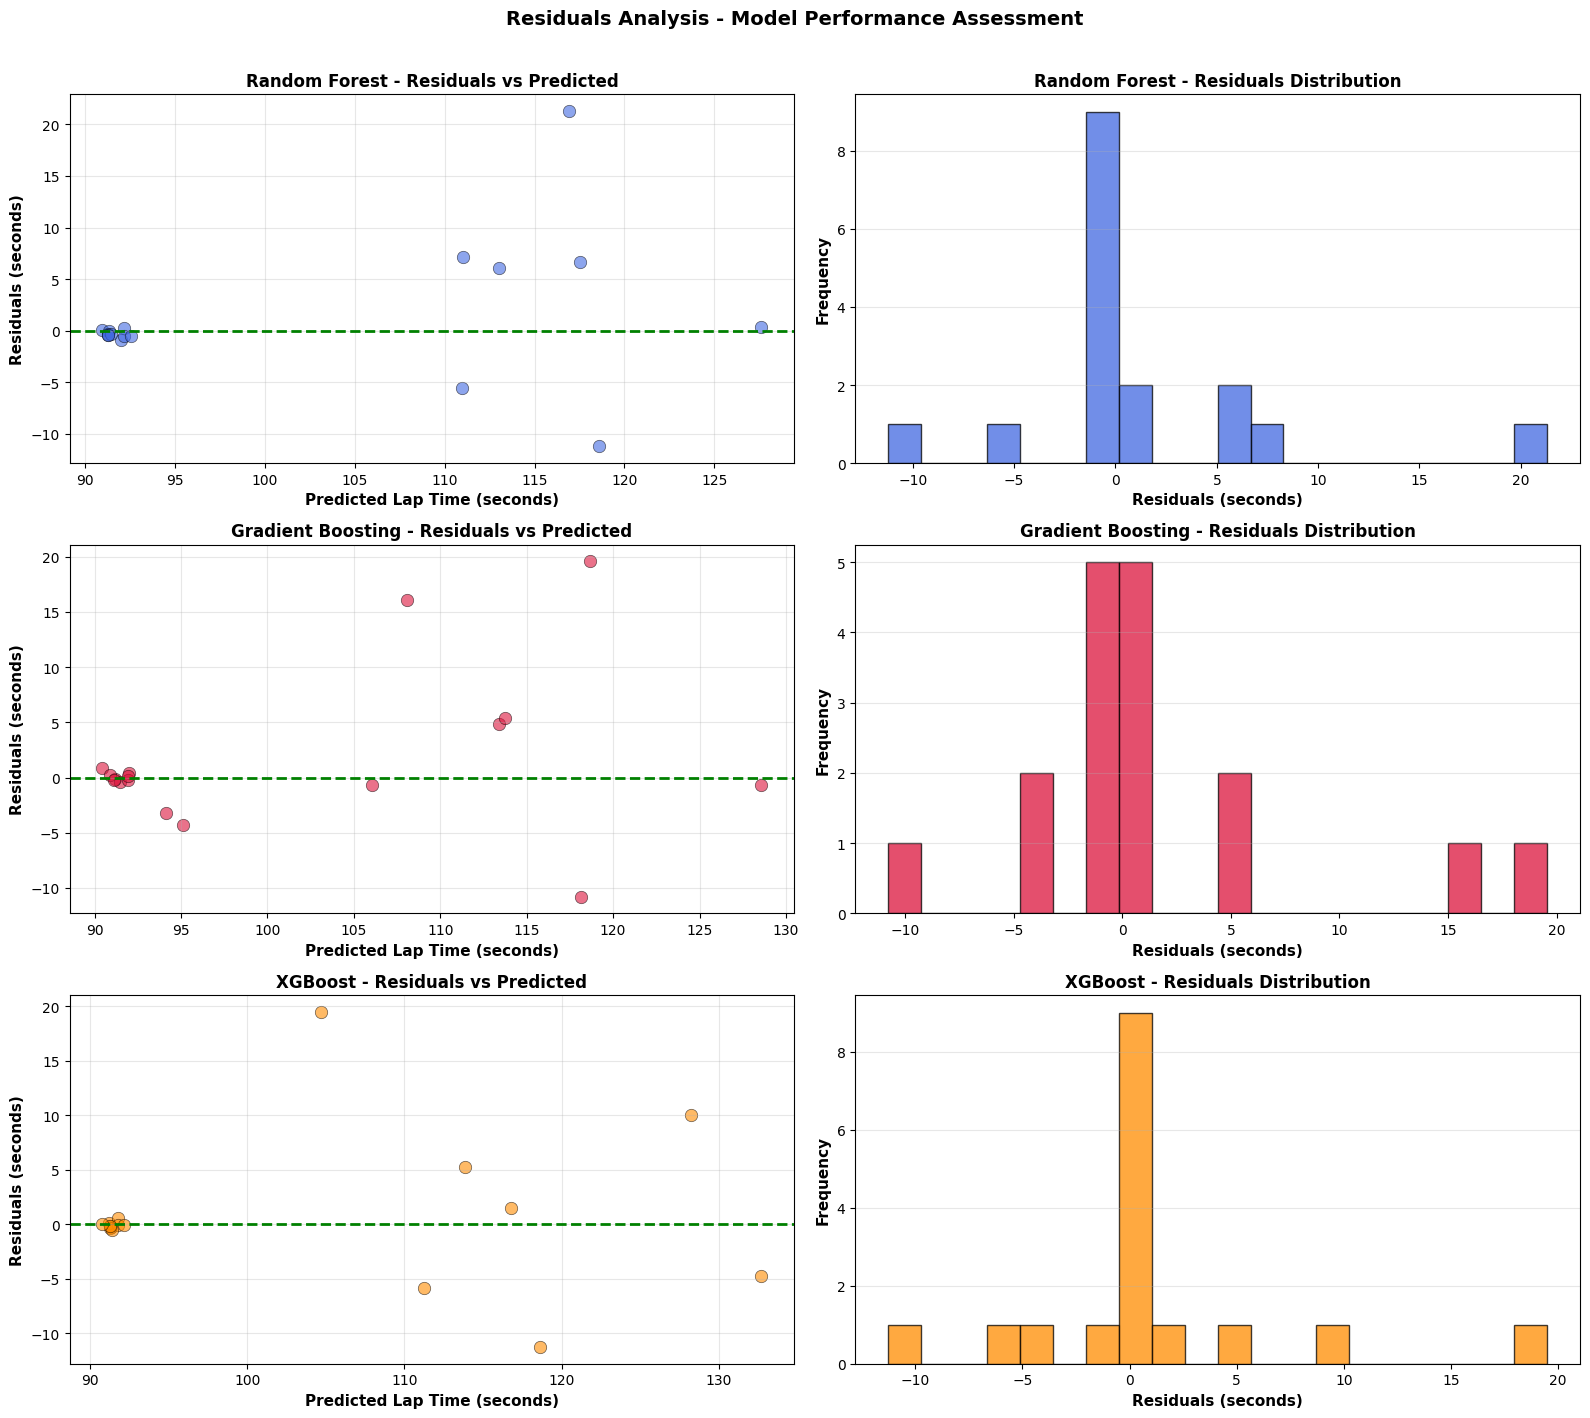

Random Forest - Mean Residuals: 1.2730, Std Dev: 6.6957
Gradient Boosting - Mean Residuals: 1.5767, Std Dev: 7.0677
XGBoost - Mean Residuals: 0.7891, Std Dev: 6.5391


In [59]:
# Residuals Analysis
rf_residuals = q_y_test - q_rf_predictions
gb_residuals = q_y_test - q_gb_predictions
xgb_residuals = q_y_test - q_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(q_rf_predictions, rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(q_gb_predictions, gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(q_xgb_predictions, xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {rf_residuals.mean():.4f}, Std Dev: {rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {gb_residuals.mean():.4f}, Std Dev: {gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {xgb_residuals.mean():.4f}, Std Dev: {xgb_residuals.std():.4f}")

##### Actual vs Predicted Fit

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

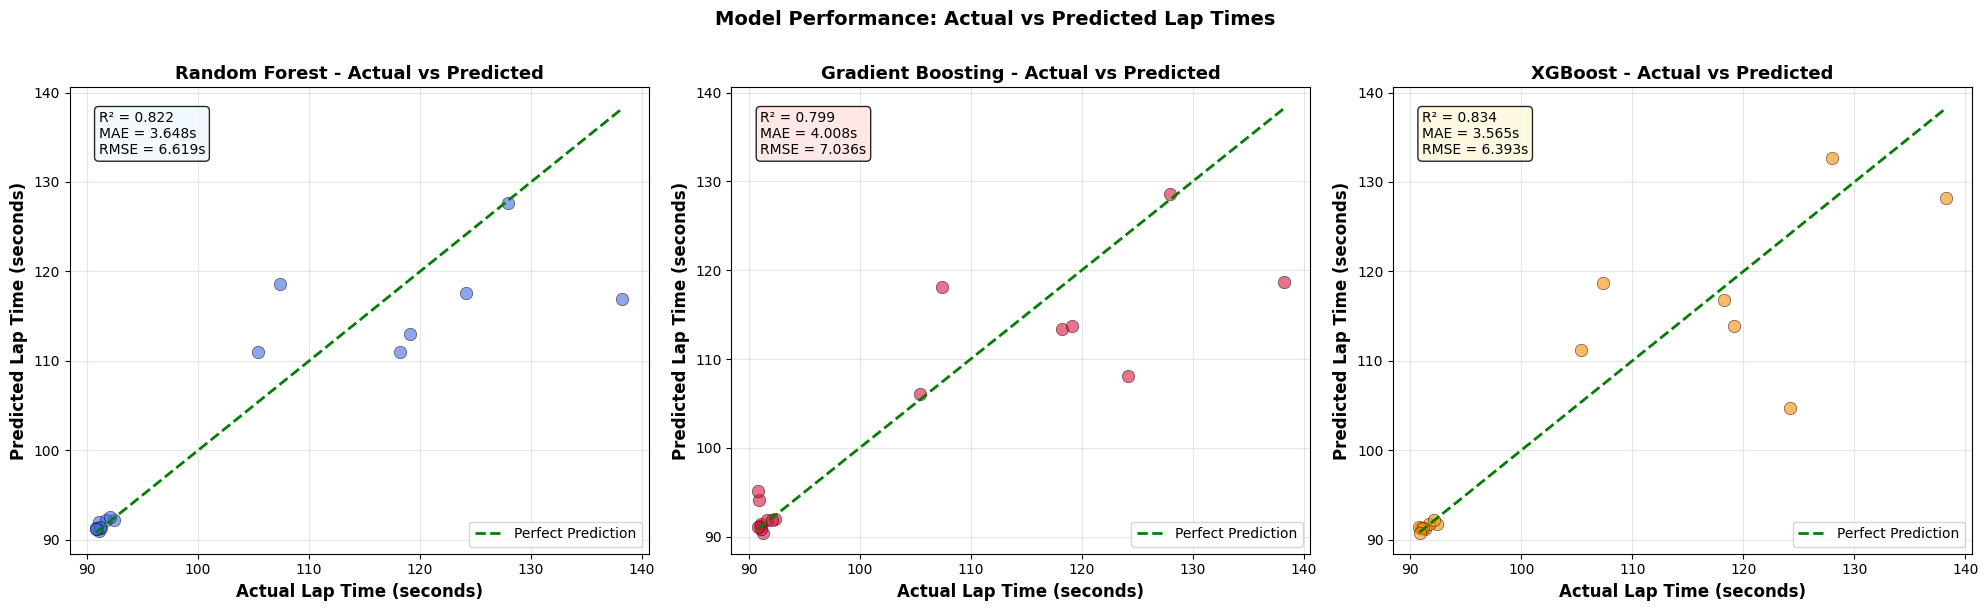

In [60]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(q_y_test, q_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(
    0.05, 0.95,
    f'R² = {q_rf_r2:.3f}\nMAE = {q_rf_mae:.3f}s\nRMSE = {q_rf_rmse:.3f}s',
    transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
 )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(q_y_test, q_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(
    0.05, 0.95,
    f'R² = {q_gb_r2:.3f}\nMAE = {q_gb_mae:.3f}s\nRMSE = {q_gb_rmse:.3f}s',
    transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.85)
 )

# XGBoost: Actual vs Predicted
axes[2].scatter(q_y_test, q_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(
    0.05, 0.95,
    f'R² = {q_xgb_r2:.3f}\nMAE = {q_xgb_mae:.3f}s\nRMSE = {q_xgb_rmse:.3f}s',
    transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='cornsilk', alpha=0.85)
 )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Qualifying Pace Projection

This scenario section uses each driver's best validation model (with a global fallback) to estimate how qualifying-style lap time changes as tyre life increases under controlled assumptions.

Treat the output as a sensitivity study rather than an exact forecast. It is most useful for comparing relative driver and team behavior under the same modeled conditions.

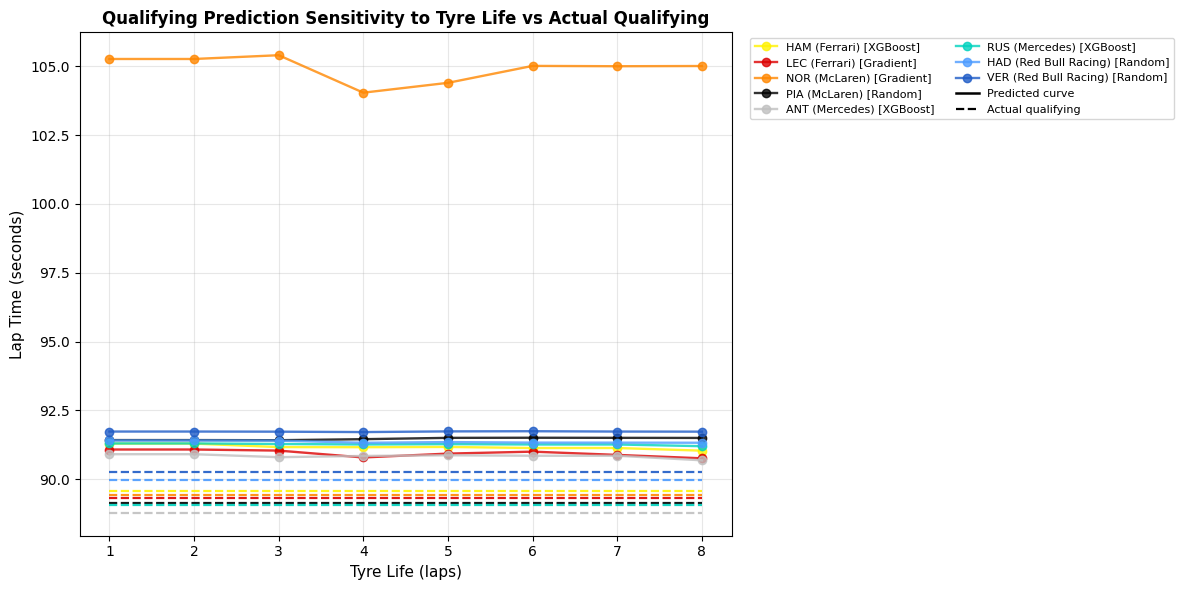

Global fallback model: XGBoost Regression
Drivers with personalized model selection: 8
Best predicted qualifying lap by driver:
           Team Driver  TyreLife  PredictedLapTimeSec PredictedLapTime  LapTimeSec ActualLapTime                    ModelUsed
       Mercedes    ANT         8            90.686554         1:30.687      88.778      1:28.778           XGBoost Regression
        Ferrari    LEC         8            90.759410         1:30.759      89.303      1:29.303 Gradient Boosting Regression
        Ferrari    HAM         8            91.036827         1:31.037      89.567      1:29.567           XGBoost Regression
       Mercedes    RUS         8            91.199852         1:31.200      89.076      1:29.076           XGBoost Regression
Red Bull Racing    HAD         4            91.322748         1:31.323      89.978      1:29.978     Random Forest Regression
        McLaren    PIA         3            91.417020         1:31.417      89.132      1:29.132     Random Forest R

In [61]:
# Format lap time in minutes:seconds.milliseconds
def format_lap_time(seconds: float) -> str:
    mins = int(seconds // 60)
    secs = seconds - mins * 60
    return f"{mins}:{secs:06.3f}"

# Build global and driver-level model mapping
model_lookup = {
    'Random Forest Regression': q_rf_model,
    'Gradient Boosting Regression': q_gb_model,
    'XGBoost Regression': q_xgb_model
}

if q_rf_r2 >= q_gb_r2 and q_rf_r2 >= q_xgb_r2:
    global_model_name = 'Random Forest Regression'
elif q_gb_r2 >= q_rf_r2 and q_gb_r2 >= q_xgb_r2:
    global_model_name = 'Gradient Boosting Regression'
else:
    global_model_name = 'XGBoost Regression'

global_model = model_lookup[global_model_name]

driver_best_model = {}
if 'q_driver_mae' in globals() and isinstance(q_driver_mae, pd.DataFrame) and not q_driver_mae.empty:
    driver_best_model = dict(zip(q_driver_mae['Driver'], q_driver_mae['BestModel']))

# Use the most common track status as a qualifying-simulation default
if 'TrackStatus' in top_teams_df.columns and top_teams_df['TrackStatus'].notna().any():
    default_track_status = top_teams_df['TrackStatus'].mode().iloc[0]
else:
    default_track_status = 1

# Build one representative row per driver from the top-team practice data
driver_profile = (
    top_teams_df.groupby('Driver', as_index=False)
    .agg({
        'Team': lambda x: x.mode().iloc[0],
        'LapNumber': 'median',
        'Stint': 'median',
        'SpeedST': 'median',
        'Compound': lambda x: x.mode().iloc[0],
    })
)
driver_profile = driver_profile[driver_profile['Team'].isin(top_teams)].copy()

tyre_life_range = list(range(1, 9))
sensitivity_rows = []

for _, row in driver_profile.iterrows():
    for tyre_life in tyre_life_range:
        sensitivity_rows.append({
            'LapNumber': int(round(row['LapNumber'])),
            'TyreLife': tyre_life,
            'Stint': int(round(row['Stint'])),
            'SpeedST': float(row['SpeedST']) if pd.notna(row['SpeedST']) else 320.0,
            'TrackStatus': default_track_status,
            'Compound': 'SOFT',
            'Driver': row['Driver'],
            'Team': row['Team'],
            'Session': 'Q'
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

# Predict with per-driver best model when available, otherwise global fallback model.
def predict_qualifying_row(row: pd.Series) -> float:
    best_name = driver_best_model.get(row['Driver'], global_model_name)
    model = model_lookup.get(best_name, global_model)
    return float(model.predict(pd.DataFrame([row]))[0])

sensitivity_df['PredictedLapTimeSec'] = sensitivity_df.apply(predict_qualifying_row, axis=1)
sensitivity_df['PredictedLapTime'] = sensitivity_df['PredictedLapTimeSec'].apply(format_lap_time)

# Use cleaned and filtered qualifying data prepared earlier in the notebook
if 'qualifying_top_teams_df' not in globals() or qualifying_top_teams_df is None:
    qualifying_top_teams_df = pd.read_csv(qualifying_top_teams_csv_file)

qualifying_laps = qualifying_top_teams_df.copy()
qualifying_laps = qualifying_laps[qualifying_laps['Driver'].isin(driver_profile['Driver'])].copy()
qualifying_laps = qualifying_laps[qualifying_laps['LapTime'].notna()].copy()

if not pd.api.types.is_numeric_dtype(qualifying_laps['LapTime']):
    qualifying_laps['LapTimeSec'] = pd.to_timedelta(qualifying_laps['LapTime'], errors='coerce').dt.total_seconds()
else:
    qualifying_laps['LapTimeSec'] = pd.to_numeric(qualifying_laps['LapTime'], errors='coerce')

actual_qualifying_df = (
    qualifying_laps.dropna(subset=['LapTimeSec'])
    .sort_values('LapTimeSec')
    .groupby('Driver', as_index=False)
    .first()[['Driver', 'LapTimeSec']]
)
actual_qualifying_df['ActualLapTime'] = actual_qualifying_df['LapTimeSec'].apply(format_lap_time)
actual_qualifying_times = dict(zip(actual_qualifying_df['Driver'], actual_qualifying_df['LapTimeSec']))

# Fallback palette makes this cell independent from earlier plotting cells
team_palette_local = globals().get(
    'team_palette',
    {'Mercedes': '#00D2BE', 'Red Bull Racing': '#1E5BC6', 'Ferrari': '#DC0000', 'McLaren': '#FF8700'}
)

# Plot per-driver curves grouped by team color
fig, ax = plt.subplots(figsize=(12, 6))
driver_palette = {
    'LEC': '#DC0000',
    'HAM': '#FFF200',
    'NOR': '#FF8700',
    'PIA': '#000000',
    'RUS': '#00D2BE',
    'ANT': '#C0C0C0',
    'VER': '#1E5BC6',
    'HAD': '#4C9BFF'
}

for _, row in driver_profile.sort_values(['Team', 'Driver']).iterrows():
    driver = row['Driver']
    team = row['Team']
    driver_df = sensitivity_df[sensitivity_df['Driver'] == driver].sort_values('TyreLife')
    driver_color = driver_palette.get(driver, team_palette_local.get(team, 'gray'))

    best_name = driver_best_model.get(driver, global_model_name)

    ax.plot(
        driver_df['TyreLife'],
        driver_df['PredictedLapTimeSec'],
        marker='o',
        linewidth=1.7,
        alpha=0.8,
        color=driver_color,
        label=f"{driver} ({team}) [{best_name.split()[0]}]"
    )

    if driver in actual_qualifying_times:
        ax.plot(
            tyre_life_range,
            [actual_qualifying_times[driver]] * len(tyre_life_range),
            linestyle='--',
            linewidth=1.6,
            alpha=0.9,
            color=driver_color
        )

ax.plot([], [], color='black', linewidth=1.8, label='Predicted curve')
ax.plot([], [], color='black', linestyle='--', linewidth=1.6, label='Actual qualifying')
ax.set_xlabel('Tyre Life (laps)', fontsize=11)
ax.set_ylabel('Lap Time (seconds)', fontsize=11)
ax.set_title('Qualifying Prediction Sensitivity to Tyre Life vs Actual Qualifying', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

best_by_driver = (
    sensitivity_df.sort_values('PredictedLapTimeSec')
    .groupby(['Team', 'Driver'], as_index=False)
    .first()[['Team', 'Driver', 'TyreLife', 'PredictedLapTimeSec', 'PredictedLapTime']]
    .sort_values('PredictedLapTimeSec')
    .merge(actual_qualifying_df, on='Driver', how='left')
)

if driver_best_model:
    best_by_driver['ModelUsed'] = best_by_driver['Driver'].map(driver_best_model).fillna(global_model_name)
else:
    best_by_driver['ModelUsed'] = global_model_name

print(f"Global fallback model: {global_model_name}")
print(f"Drivers with personalized model selection: {len(driver_best_model)}")
print('Best predicted qualifying lap by driver:')
print(best_by_driver.to_string(index=False))

The gap between practice-based predictions and actual qualifying times should be read as a calibration question, not just a model scorecard. Qualifying laps differ from practice laps because tyre preparation, fuel load, track evolution, and push intent are better aligned to single-lap performance.

For that reason, relative ordering and relative gaps are often more informative than raw absolute offset when the training data is limited to practice sessions.

## Race Strategy Prediction

This section extends the notebook from qualifying pace prediction into race strategy recommendation. Using degradation trends from FP1-FP3 long-run data, the analysis estimates total race time across viable one-stop and two-stop combinations and reports the primary strategy per driver (lowest projected total race time). Albert Park 2026 runs 58 laps, and at least two compounds must be used.

> **Note:** Degradation rates are fitted on FP laps with TyreLife > 3 (warm-up phase excluded). Pit stop loss is fixed at 22 s. Safety car probability is not modeled, so strategy rankings can change under neutralizations.

In [62]:
# Race and pit constants
RACE_LAPS = 53
PIT_STOP_LOSS = 22.0
WARM_UP_LAPS = 3
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

# F1 standard compound display colours and abbreviations
compound_colors = {'SOFT': '#E8002D', 'MEDIUM': '#FFF200', 'HARD': '#C8C8C8'}
compound_abbr = {'SOFT': 'S', 'MEDIUM': 'M', 'HARD': 'H'}

# Fallback lap time if model prediction is non-finite
fallback_lap_time = {'SOFT': 88.0, 'MEDIUM': 89.5, 'HARD': 91.0}

# Select best tyre degradation model by validation R2
if t_rf_r2 >= t_gb_r2 and t_rf_r2 >= t_xgb_r2:
    degrad_model = t_rf_model
    degrad_model_name = 'Random Forest (Tyre Degradation)'
elif t_gb_r2 >= t_rf_r2 and t_gb_r2 >= t_xgb_r2:
    degrad_model = t_gb_model
    degrad_model_name = 'Gradient Boosting (Tyre Degradation)'
else:
    degrad_model = t_xgb_model
    degrad_model_name = 'XGBoost (Tyre Degradation)'

print(f"Race strategy using: {degrad_model_name} (R2 = {max(t_rf_r2, t_gb_r2, t_xgb_r2):.3f})")

# Build driver profiles for personalised predictions
driver_profile_ml = (
    top_teams_df[
        top_teams_df['Session'].isin(['FP1', 'FP2', 'FP3'])
        & top_teams_df['LapTime'].notna()
        & (top_teams_df['TyreLife'] > WARM_UP_LAPS)
    ]
    .groupby('Driver', as_index=False)
    .agg({
        'Team': lambda x: x.mode().iloc[0],
        'LapNumber': 'median',
        'Stint': 'median',
        'SpeedST': 'median',
        'TrackStatus': lambda x: x.mode().iloc[0] if x.notna().any() else 1,
        'FreshTyre': lambda x: 'False'
    })
)

driver_profile_ml = driver_profile_ml[driver_profile_ml['Team'].isin(top_teams)].copy().reset_index(drop=True)
driver_context = driver_profile_ml.set_index('Driver').to_dict(orient='index')

# Function to build one input row for the model based on driver context and tyre life
def build_stint_input_row(driver: str, compound: str, tyre_life: int) -> dict:
    ctx = driver_context.get(driver, {})
    return {
        'LapNumber': int(round(ctx.get('LapNumber', 20))),
        'TyreLife': tyre_life,
        'Stint': int(round(ctx.get('Stint', 2))),
        'SpeedST': float(ctx.get('SpeedST', 315.0)),
        'TrackStatus': ctx.get('TrackStatus', 1),
        'Compound': compound,
        'Driver': driver,
        'Team': ctx.get('Team', 'Unknown'),
        'Session': 'R',
        'FreshTyre': 'False'
    }

# Precompute cumulative stint time lookup to avoid repeated model.predict calls in sorting loops.
def build_driver_stint_cache(driver: str) -> dict:
    rows = [
        build_stint_input_row(driver, compound, tyre_life)
        for compound in COMPOUNDS
        for tyre_life in range(1, RACE_LAPS + 1)
    ]
    input_df = pd.DataFrame(rows)
    predicted = degrad_model.predict(input_df)

    if not np.all(np.isfinite(predicted)):
        for i, row in input_df.iterrows():
            if not np.isfinite(predicted[i]):
                predicted[i] = fallback_lap_time.get(row['Compound'], 90.0)

    input_df['PredLapTime'] = predicted
    input_df['CumStintTime'] = input_df.groupby('Compound')['PredLapTime'].cumsum()

    cache = {}
    for compound in COMPOUNDS:
        compound_cum = input_df.loc[input_df['Compound'] == compound, 'CumStintTime'].to_numpy()
        for laps in range(1, RACE_LAPS + 1):
            cache[(compound, laps)] = float(compound_cum[laps - 1])

    return cache

# Strategy universe, ranking, and driver recommendations

# Pit window sweep ranges
ONE_STOP = list(range(15, 44, 2))
TWO_W1 = list(range(12, 25, 3))
TWO_W2 = list(range(28, 47, 3))

# Build strategy universe (times are computed per driver below)
strategies = []
strategy_id = 0

for c1, c2 in product(COMPOUNDS, COMPOUNDS):
    if c1 == c2:
        continue
    for w in ONE_STOP:
        s1, s2 = w, RACE_LAPS - w
        if s1 < 5 or s2 < 5:
            continue
        strategies.append({
            'StrategyId': strategy_id,
            'Type': '1-Stop',
            'Compounds': f"{c1} -> {c2}",
            'Stint1': f"{c1} ({s1} laps)",
            'Stint2': f"{c2} ({s2} laps)",
            'Stint3': '-',
            'Pit1_Lap': w,
            'Pit2_Lap': None,
            'TotalTime': 0.0,
            'Stints_raw': [(c1, s1), (c2, s2)]
        })
        strategy_id += 1

for c1, c2, c3 in product(COMPOUNDS, COMPOUNDS, COMPOUNDS):
    if len({c1, c2, c3}) < 2:
        continue
    for w1, w2 in product(TWO_W1, TWO_W2):
        if w2 <= w1 + 8:
            continue
        s1, s2, s3 = w1, w2 - w1, RACE_LAPS - w2
        if s1 < 5 or s2 < 5 or s3 < 5:
            continue
        strategies.append({
            'StrategyId': strategy_id,
            'Type': '2-Stop',
            'Compounds': f"{c1} -> {c2} -> {c3}",
            'Stint1': f"{c1} ({s1} laps)",
            'Stint2': f"{c2} ({s2} laps)",
            'Stint3': f"{c3} ({s3} laps)",
            'Pit1_Lap': w1,
            'Pit2_Lap': w2,
            'TotalTime': 0.0,
            'Stints_raw': [(c1, s1), (c2, s2), (c3, s3)]
        })
        strategy_id += 1

print(
    f"Strategies generated: {len(strategies)} "
    f"({sum(1 for s in strategies if s['Type']=='1-Stop')} one-stop, "
    f"{sum(1 for s in strategies if s['Type']=='2-Stop')} two-stop)"
)

def fmt_race_time(s: float) -> str:
    h = int(s // 3600)
    m = int((s % 3600) // 60)
    return f"{h}:{m:02d}:{s % 60:05.2f}"

recommendations = []
for driver in driver_profile_ml['Driver']:
    stint_cache = build_driver_stint_cache(driver)

    scored_rows = []
    for strategy in strategies:
        stint_total = sum(stint_cache[(compound, laps)] for compound, laps in strategy['Stints_raw'])
        pit_loss = (len(strategy['Stints_raw']) - 1) * PIT_STOP_LOSS
        total_time = stint_total + pit_loss

        scored_rows.append({
            'StrategyId': strategy['StrategyId'],
            'TotalTime': total_time
        })

    scored_df = pd.DataFrame(scored_rows).sort_values('TotalTime').reset_index(drop=True)
    primary_id = int(scored_df.loc[0, 'StrategyId'])
    primary_time = float(scored_df.loc[0, 'TotalTime'])

    primary_strategy = next(s for s in strategies if s['StrategyId'] == primary_id)

    strategy = {k: v for k, v in primary_strategy.items() if k not in ['Stints_raw', 'StrategyId']}
    strategy.update({
        'Driver': driver,
        'Team': driver_context[driver]['Team'],
        'Rec': 'Primary',
        'TotalTime': primary_time
    })
    recommendations.append(strategy)

rec_df = pd.DataFrame(recommendations)
rec_df['TotalRaceTime'] = rec_df['TotalTime'].apply(fmt_race_time)

print("\nSuggested Race Strategies per Driver")
print(
    rec_df[[
        'Team', 'Driver', 'Rec', 'Type', 'Compounds',
        'Stint1', 'Stint2', 'Stint3', 'Pit1_Lap', 'Pit2_Lap', 'TotalRaceTime'
    ]]
    .sort_values(['Team', 'Driver', 'Rec'])
    .to_string(index=False)
)

Race strategy using: Random Forest (Tyre Degradation) (R2 = 0.786)
Strategies generated: 858 (90 one-stop, 768 two-stop)

Suggested Race Strategies per Driver
           Team Driver     Rec   Type              Compounds           Stint1           Stint2           Stint3  Pit1_Lap  Pit2_Lap TotalRaceTime
        Ferrari    HAM Primary 2-Stop SOFT -> SOFT -> MEDIUM   SOFT (15 laps)   SOFT (28 laps) MEDIUM (10 laps)        15      43.0    1:23:34.52
        Ferrari    LEC Primary 2-Stop MEDIUM -> SOFT -> SOFT MEDIUM (12 laps)   SOFT (28 laps)   SOFT (13 laps)        12      40.0    1:23:46.11
        McLaren    NOR Primary 1-Stop         MEDIUM -> HARD MEDIUM (43 laps)   HARD (10 laps)                -        43       NaN    1:47:52.47
        McLaren    PIA Primary 2-Stop SOFT -> SOFT -> MEDIUM   SOFT (12 laps)   SOFT (31 laps) MEDIUM (10 laps)        12      43.0    1:22:43.90
       Mercedes    ANT Primary 2-Stop MEDIUM -> SOFT -> SOFT MEDIUM (15 laps)   SOFT (19 laps)   SOFT (19 laps)

## Conclusion

This notebook delivers an end-to-end workflow for Australian GP qualifying pace analysis using FP1-FP3 data. It covers data extraction, cleaning, top-team filtering, exploratory diagnostics, model benchmarking, and driver-level tyre-life scenario projections.

The analysis shows that lap time is shaped by multiple interacting factors rather than any single dominant variable. Tyre condition, session context, stint progression, and straight-line speed all matter, but their combined effect is more informative than their individual averages or simple correlations.

The model results support the use of ensemble regressors for this problem, especially when the objective is relative pace comparison and scenario exploration. Absolute qualifying prediction remains harder and would benefit from calibration or direct qualifying-session training data.

### Key Findings

1. Practice pace varies not just by team but by session structure, stint pattern, and lap context, which makes raw averages incomplete on their own.
2. Tyre compound and tyre life both influence lap time, but the effect is noisy enough that context-aware modeling is necessary.
3. Ensemble models outperform the naive baseline, which confirms that the feature set captures usable predictive signal.
4. The qualifying projection is most valuable as a controlled scenario tool for comparing drivers and teams under shared assumptions.

### Recommendations

#### For Performance Engineering

1. Apply a post-model calibration step before using practice-trained outputs as absolute qualifying estimates.
2. Treat relative team and driver deltas as the most reliable operational signal when absolute offset remains unstable.
3. Use tyre-life sensitivity results together with run-plan context rather than in isolation.

#### For Data Science

1. Separate qualifying-oriented laps from general practice laps more aggressively to reduce systematic bias.
2. Add richer inputs such as sector splits, mini-sector traces, traffic indicators, and weather or track evolution variables.
3. Compare model quality not only on point accuracy but also on calibration and stability across sessions.

#### For Strategy and Simulation

1. Use the projection outputs as scenario guidance, not as deterministic single-lap truth.
2. Pair pace estimates with uncertainty ranges when comparing setup or tyre-age alternatives.
3. Revisit the comparison after each session update so decisions reflect the latest state of the weekend.

#### Next Analysis Steps

1. Extend the dataset to include qualifying and race laps so the model can learn across multiple performance contexts.
2. Evaluate additional algorithms or tuned variants, including a fuller XGBoost diagnostic pass and calibrated ensemble comparisons.
3. Add uncertainty-aware outputs such as prediction intervals or quantile models for decision support.
4. Test both shared and driver-specific models to measure where specialization improves forecast quality.

In [63]:
import numpy as np
import pandas as pd


def _pred_vs_actual_summary(y_true, model_preds: dict, scope: str) -> pd.DataFrame:
    rows = []
    y_true = np.asarray(y_true, dtype=float)

    for model_name, pred in model_preds.items():
        pred = np.asarray(pred, dtype=float)
        if len(pred) != len(y_true):
            rows.append({
                "scope": scope,
                "model": model_name,
                "n": len(pred),
                "status": "length_mismatch",
            })
            continue

        error = pred - y_true
        over_mask = error > 0

        rows.append({
            "scope": scope,
            "model": model_name,
            "n": len(error),
            "overpred_count": int(over_mask.sum()),
            "overpred_pct": float(over_mask.mean() * 100.0),
            "mean_error_s": float(error.mean()),
            "median_error_s": float(np.median(error)),
            "p90_error_s": float(np.percentile(error, 90)),
            "max_error_s": float(error.max()),
            "min_error_s": float(error.min()),
            "mae_s": float(np.abs(error).mean()),
            "rmse_s": float(np.sqrt(np.mean(error ** 2))),
            "status": "ok",
        })

    return pd.DataFrame(rows)


qualifying_preds = {
    "RF": q_rf_predictions,
    "GB": q_gb_predictions,
    "XGB": q_xgb_predictions,
}

top_team_preds = {
    "RF": t_rf_predictions,
    "GB": t_gb_predictions,
    "XGB": t_xgb_predictions,
}

qualifying_summary = _pred_vs_actual_summary(q_y_test, qualifying_preds, "qualifying")
top_teams_summary = _pred_vs_actual_summary(t_y_test, top_team_preds, "top_teams")

summary = pd.concat([qualifying_summary, top_teams_summary], ignore_index=True)
summary

,scope,model,n,overpred_count,overpred_pct,mean_error_s,median_error_s,p90_error_s,max_error_s,min_error_s,mae_s,rmse_s,status
0,qualifying,RF,17,10,58.823529,-1.273038,0.324162,2.761091,11.218514,-21.293465,3.647780,6.619354,ok
1,qualifying,GB,17,9,52.941176,-1.576728,0.149567,3.652772,10.783898,-19.564559,4.008210,7.035665,ok
2,qualifying,XGB,17,10,58.823529,-0.789086,0.103333,5.201489,11.265492,-19.484338,3.564800,6.392789,ok
3,top_teams,RF,74,44,59.459459,1.932098,0.133141,12.892487,25.742354,-7.861178,3.124808,6.361521,ok
4,top_teams,GB,74,43,58.108108,2.042564,0.271648,9.574984,22.894763,-8.994847,3.136289,6.420207,ok
5,top_teams,XGB,74,37,50.000000,1.831219,0.000740,11.032237,25.417796,-7.923459,2.739314,6.602128,ok


In [64]:
import numpy as np
import pandas as pd


def _best_model_name(summary_df: pd.DataFrame, scope_name: str) -> str:
    scoped = summary_df[summary_df["scope"] == scope_name].copy()
    return scoped.sort_values("mae_s", ascending=True).iloc[0]["model"]


def _pred_array(model_name: str, q_or_t: str) -> np.ndarray:
    if q_or_t == "q":
        return {
            "RF": q_rf_predictions,
            "GB": q_gb_predictions,
            "XGB": q_xgb_predictions,
        }[model_name]
    return {
        "RF": t_rf_predictions,
        "GB": t_gb_predictions,
        "XGB": t_xgb_predictions,
    }[model_name]


def _bias_breakdown(X_test, y_test, pred, scope_name: str):
    df = X_test.copy()
    df = pd.DataFrame(df)
    y = np.asarray(y_test, dtype=float)
    p = np.asarray(pred, dtype=float)
    err = p - y

    df["actual_s"] = y
    df["pred_s"] = p
    df["error_s"] = err
    df["overpred"] = err > 0

    if "TyreLife" in df.columns:
        df["TyreLifeBin"] = pd.cut(
            df["TyreLife"], bins=[-1, 4, 9, 14, 19, 100], labels=["0-4", "5-9", "10-14", "15-19", "20+"],
        )

    breakdowns = {}
    for col in ["Team", "Compound", "TrackStatus", "TyreLifeBin"]:
        if col in df.columns:
            grp = (
                df.groupby(col, observed=True)
                .agg(
                    n=("error_s", "size"),
                    overpred_pct=("overpred", lambda s: float(np.mean(s) * 100.0)),
                    mean_error_s=("error_s", "mean"),
                    mae_s=("error_s", lambda s: float(np.mean(np.abs(s)))),
                )
                .sort_values(["mean_error_s", "overpred_pct"], ascending=False)
            )
            breakdowns[col] = grp

    print(f"\n=== {scope_name} residual overview ===")
    print(f"samples: {len(df)}")
    print(f"mean error (pred-actual): {df['error_s'].mean():.3f} s")
    print(f"overprediction rate: {(df['overpred'].mean() * 100):.1f}%")

    for key, table in breakdowns.items():
        print(f"\n-- Bias by {key} --")
        display(table.head(10))


best_q = _best_model_name(summary, "qualifying")
best_t = _best_model_name(summary, "top_teams")

print(f"Best qualifying model by MAE: {best_q}")
print(f"Best top-team model by MAE: {best_t}")

_bias_breakdown(q_X_test, q_y_test, _pred_array(best_q, "q"), f"qualifying ({best_q})")
_bias_breakdown(t_X_test, t_y_test, _pred_array(best_t, "t"), f"top_teams ({best_t})")

Best qualifying model by MAE: XGB
Best top-team model by MAE: XGB

=== qualifying (XGB) residual overview ===
samples: 17
mean error (pred-actual): -0.789 s
overprediction rate: 58.8%

-- Bias by Team --


,n,overpred_pct,mean_error_s,mae_s
Team,,,,
McLaren,4,75.000000,3.895471,4.196583
Ferrari,8,50.000000,-0.004713,1.722942
Mercedes,3,66.666667,-3.270282,3.403618
Red Bull Racing,2,50.000000,-9.573901,9.910437



-- Bias by Compound --


,n,overpred_pct,mean_error_s,mae_s
Compound,,,,
SOFT,17,58.823529,-0.789086,3.5648



-- Bias by TrackStatus --


...

,n,overpred_pct,mean_error_s,mae_s
Compound,,,,
SOFT,32,50.000000,2.130886,2.994016
MEDIUM,29,44.827586,1.712870,3.002788
HARD,13,61.538462,1.357587,1.524607



-- Bias by TrackStatus --


,n,overpred_pct,mean_error_s,mae_s
TrackStatus,,,,
1,71,50.704225,1.90476,2.848728
12,3,33.333333,0.09076,0.149846



-- Bias by TyreLifeBin --


,n,overpred_pct,mean_error_s,mae_s
TyreLifeBin,,,,
20+,3,33.333333,7.020286,9.924911
5-9,29,55.172414,2.315198,3.315883
10-14,9,22.222222,2.071441,2.830302
0-4,20,55.000000,1.772917,1.815240
15-19,13,53.846154,-0.522515,1.153570


In [65]:
# Inspect largest positive residuals for top-team best model (XGB from prior cell)
outlier_df = pd.DataFrame(t_X_test).copy()
outlier_df["actual_s"] = np.asarray(t_y_test, dtype=float)
outlier_df["pred_s"] = np.asarray(t_xgb_predictions, dtype=float)
outlier_df["error_s"] = outlier_df["pred_s"] - outlier_df["actual_s"]
outlier_df = outlier_df.sort_values("error_s", ascending=False)

cols_to_show = [
    c for c in ["Driver", "Team", "Compound", "TyreLife", "LapNumber", "TrackStatus", "actual_s", "pred_s", "error_s"]
    if c in outlier_df.columns
]

print("Top 12 overpredicted laps (pred - actual):")
display(outlier_df[cols_to_show].head(12))

print("\nTop 12 underpredicted laps (pred - actual):")
display(outlier_df[cols_to_show].tail(12).sort_values("error_s", ascending=True))

Top 12 overpredicted laps (pred - actual):


,Driver,Team,Compound,TyreLife,LapNumber,TrackStatus,actual_s,pred_s,error_s
243,HAD,Red Bull Racing,MEDIUM,20.0,25.0,1,102.648,128.065796,25.417796
97,ANT,Mercedes,SOFT,10.0,19.0,1,97.361,119.412949,22.051949
266,HAM,Ferrari,SOFT,8.0,21.0,1,103.865,124.863220,20.998220
356,HAD,Red Bull Racing,MEDIUM,6.0,6.0,1,112.988,131.782166,18.794166
277,RUS,Mercedes,SOFT,7.0,7.0,1,109.080,127.613754,18.533754
105,VER,Red Bull Racing,MEDIUM,3.0,3.0,1,117.236,134.206680,16.970680
278,RUS,Mercedes,SOFT,9.0,27.0,1,117.033,133.459061,16.426061
29,ANT,Mercedes,HARD,2.0,2.0,1,108.692,123.364998,14.672998
360,HAD,Red Bull Racing,MEDIUM,7.0,7.0,1,92.870,95.407127,2.537127
96,LEC,Ferrari,SOFT,7.0,17.0,1,91.955,94.020714,2.065714



Top 12 underpredicted laps (pred - actual):


,Driver,Team,Compound,TyreLife,LapNumber,TrackStatus,actual_s,pred_s,error_s
37,HAD,Red Bull Racing,MEDIUM,15.0,20.0,1,105.676,97.752541,-7.923459
190,NOR,McLaren,SOFT,5.0,11.0,1,119.001,111.781982,-7.219018
345,HAD,Red Bull Racing,MEDIUM,21.0,26.0,1,130.886,126.588676,-4.297324
128,LEC,Ferrari,SOFT,9.0,18.0,1,118.211,114.634613,-3.576387
180,PIA,McLaren,MEDIUM,15.0,21.0,1,99.330,96.535477,-2.794523
193,HAD,Red Bull Racing,SOFT,5.0,17.0,1,118.980,117.247169,-1.732831
30,PIA,McLaren,MEDIUM,12.0,20.0,1,97.184,95.798271,-1.385729
140,PIA,McLaren,MEDIUM,13.0,21.0,1,96.152,95.531731,-0.620269
333,PIA,McLaren,MEDIUM,13.0,21.0,1,96.152,95.531731,-0.620269
226,HAM,Ferrari,HARD,5.0,5.0,1,93.822,93.217422,-0.604578


In [66]:
print("Qualifying metrics")
print({
    "RF": {"MAE": q_rf_mae, "RMSE": q_rf_rmse, "R2": q_rf_r2},
    "GB": {"MAE": q_gb_mae, "RMSE": q_gb_rmse, "R2": q_gb_r2},
    "XGB": {"MAE": q_xgb_mae, "RMSE": q_xgb_rmse, "R2": q_xgb_r2},
})
print("\nTop-team metrics")
print({
    "RF": {"MAE": t_rf_mae, "RMSE": t_rf_rmse, "R2": t_rf_r2},
    "GB": {"MAE": t_gb_mae, "RMSE": t_gb_rmse, "R2": t_gb_r2},
    "XGB": {"MAE": t_xgb_mae, "RMSE": t_xgb_rmse, "R2": t_xgb_r2},
})
print(f"\nTop-team baseline R2: {t_baseline_r2}")

Qualifying metrics
{'RF': {'MAE': 3.647779583644573, 'RMSE': np.float64(6.6193535975051425), 'R2': 0.8222521088273382}, 'GB': {'MAE': 4.008209723071522, 'RMSE': np.float64(7.035664554129974), 'R2': 0.7991908283777898}, 'XGB': {'MAE': 3.564799531824449, 'RMSE': np.float64(6.392788735177786), 'R2': 0.8342116537991561}}

Top-team metrics
{'RF': {'MAE': 3.124808448141812, 'RMSE': np.float64(6.361521378149229), 'R2': 0.7863209043074152}, 'GB': {'MAE': 3.1362890089242326, 'RMSE': np.float64(6.420206909566616), 'R2': 0.7823603070915902}, 'XGB': {'MAE': 2.7393142914643156, 'RMSE': np.float64(6.6021276181406865), 'R2': 0.7698516397877556}}

Top-team baseline R2: -0.00946231556334376
